In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import io
import anndata
import random
from matplotlib.ticker import MaxNLocator

random.seed(777)

import celloracle as co
co.__version__

# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 6]
plt.rcParams["savefig.dpi"] = 300

#GRN model construction and network analysis
#https://morris-lab.github.io/CellOracle.documentation/tutorials/networkanalysis.html


/opt/conda/envs/celloracle2/lib/python3.8/site-packages/logomaker/src/validate.py:98: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if matrix_type is 'information':
/opt/conda/envs/celloracle2/lib/python3.8/site-packages/logomaker/src/validate.py:104: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif matrix_type is 'probability':


In [2]:
#Set working directory
os.chdir("/storage1/fs1/jmillman/Active/DigitalTwin")

save_folder = "outputs/celloracle_figures"


# GRN model construction preprocessing

In [3]:
X = io.mmread('checkpoints/DT_Subset_Delta_matrix.mtx')

adata= anndata.AnnData(X=X.transpose().tocsr())

metadata = pd.read_csv('checkpoints/DT_Subset_Delta_metadata.csv')

with open ('checkpoints/DT_Subset_Delta_gene_names.csv', 'r' ) as f:
    gene_names = f.read().splitlines()
    
adata.obs = metadata
adata.obs.index = adata.obs['barcode']
adata.var.index = gene_names

pca = pd.read_csv('checkpoints/DT_Subset_Delta_pca.csv')
pca.index = adata.obs.index

adata.obsm['X_pca'] = pca.to_numpy()
adata.obsm['X_umap'] = np.vstack((adata.obs['UMAP_1'].to_numpy(), 
                                  adata.obs['UMAP_2'].to_numpy())).T

... storing 'orig.ident' as categorical
... storing 'modality' as categorical
... storing 'dataset' as categorical
... storing 'protocol' as categorical
... storing 'stage' as categorical
... storing 'day' as categorical
... storing 'cellsource' as categorical
... storing 'gender' as categorical
... storing 'modality.1' as categorical
... storing 'dataset.1' as categorical
... storing 'protocol.1' as categorical
... storing 'stage.1' as categorical
... storing 'day.1' as categorical
... storing 'cellsource.1' as categorical
... storing 'gender.1' as categorical
... storing 'celltype_labelled_by_protocol' as categorical
... storing 'celltype_Delta_subset' as categorical


PP        2680
EP        2492
Delta     1881
eDelta     530
Name: celltype_Delta_subset, dtype: int64


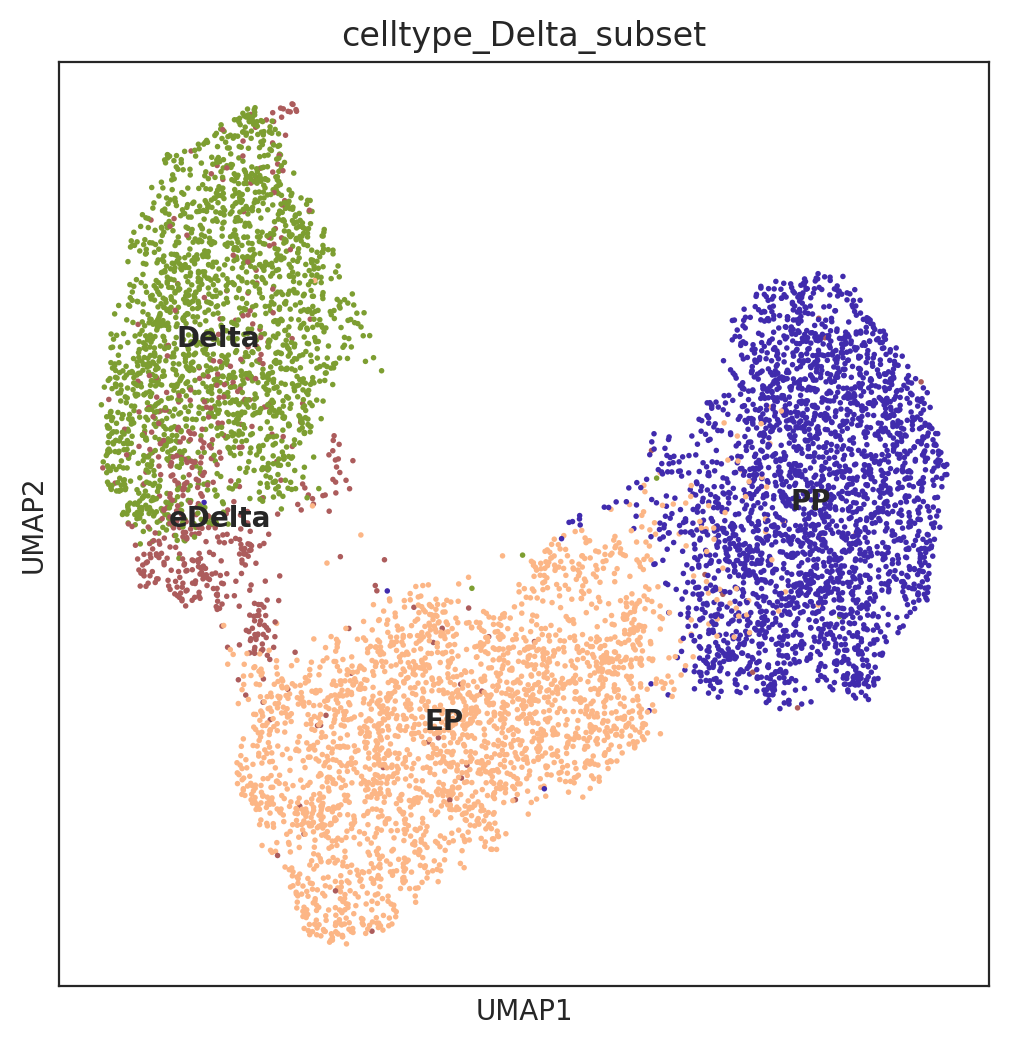

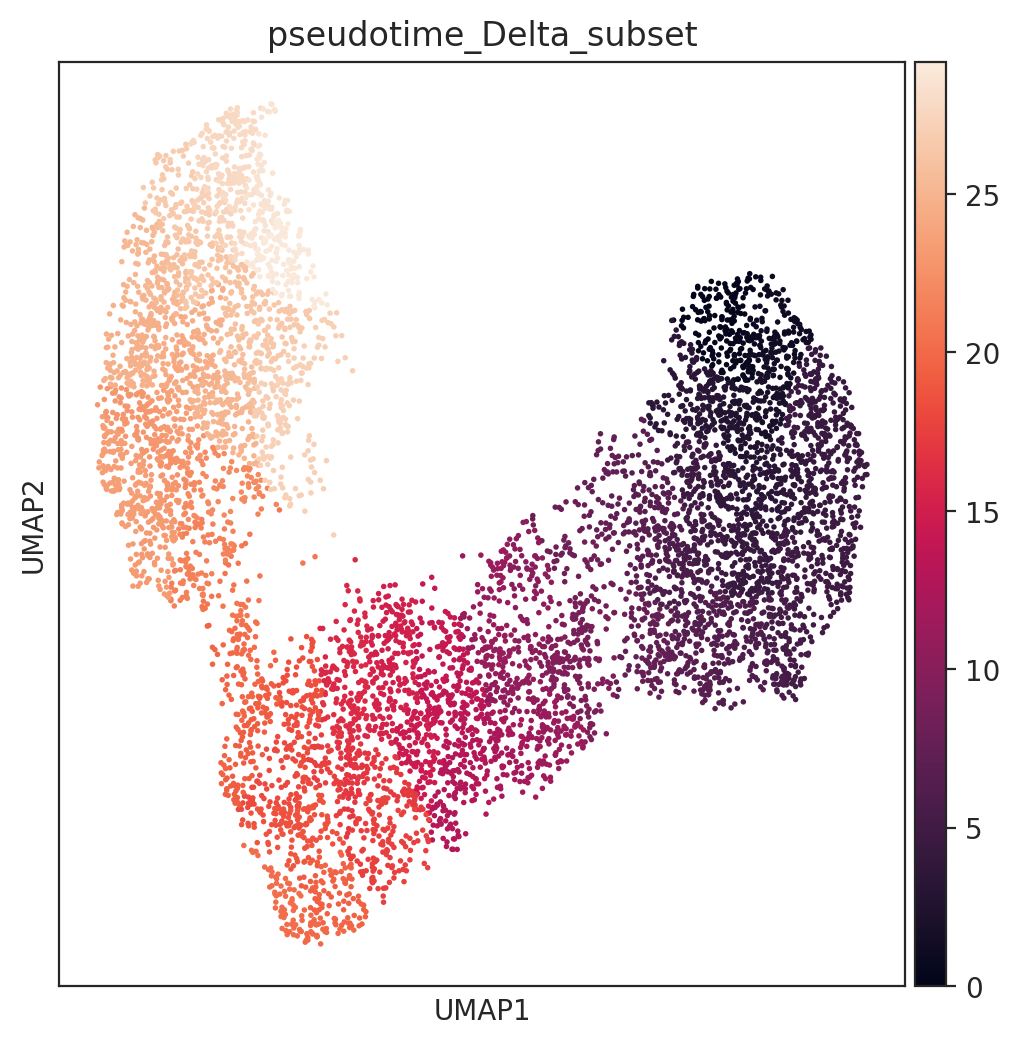

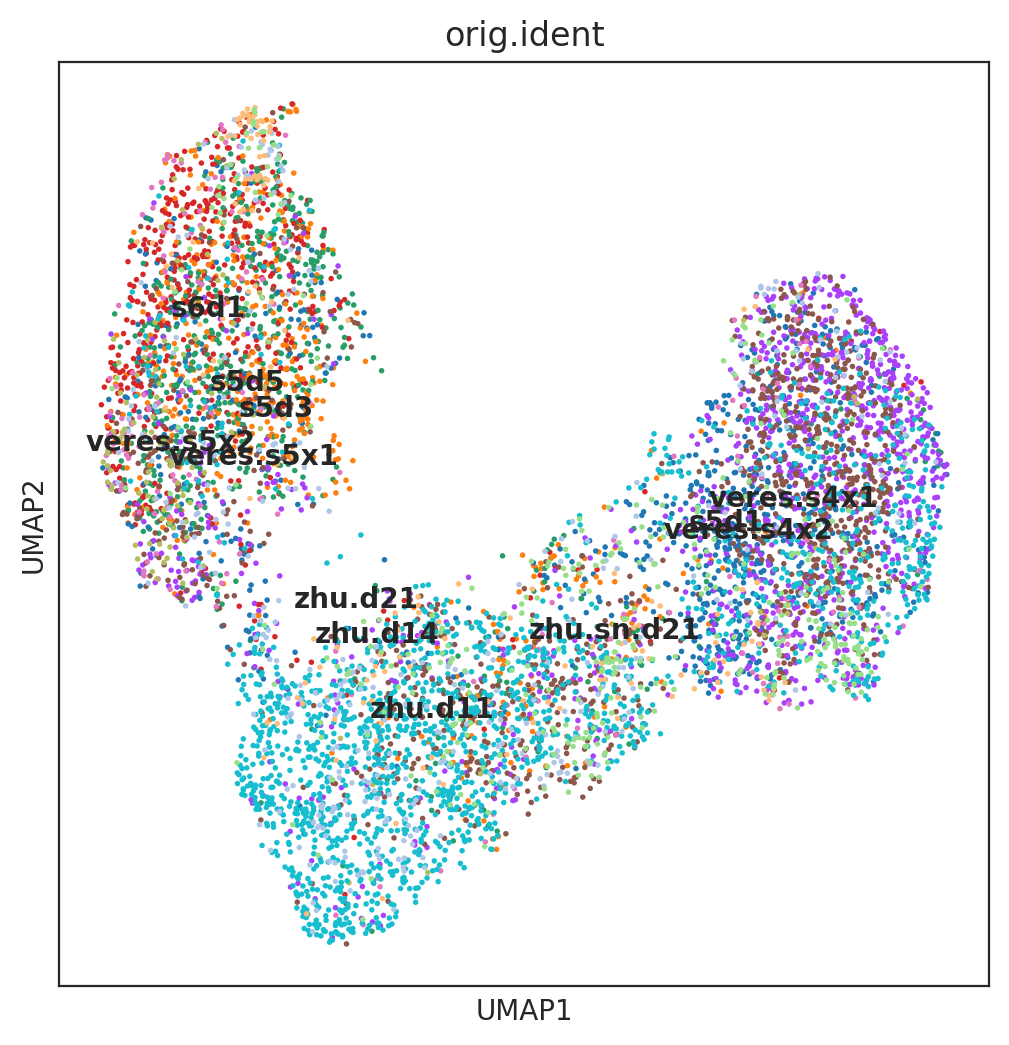

In [4]:
celltype_Delta_subset_colors = ["#7d9e31", '#fcb686',"#402bad","#AC5C5C"]
    
'''
        "PP"       = "#402bad", # deep indigo
        "EP"      = "#fcb686", # crema
        "eDelta"    = "#AC5C5C", #  
        "Delta"    = "#7d9e31"
'''

adata.uns["celltype_Delta_subset_colors"] = celltype_Delta_subset_colors

# Check how many cells are per cell type
cell_types = adata.obs['celltype_Delta_subset']
cluster_counts = pd.value_counts(cell_types)
print(cluster_counts)

sc.pl.umap(adata, color='celltype_Delta_subset', legend_loc='on data')
sc.pl.umap(adata, color='pseudotime_Delta_subset', legend_loc='on data')
sc.pl.umap(adata, color='orig.ident', legend_loc='on data')

In [5]:
# Filter highly variable genes
filter_result = sc.pp.filter_genes_dispersion(adata.X, flavor='seurat', 
                                              n_top_genes=3000, log=False)

# Additional genes to include
# Including genes: from Differentiated human stem cells resemble fetal, not adult, β cells
additional_genes = ['ABCC8','ACOX2','ACSS3','AFP','AHR','ALDOA','ALX1',
                    'AR','ARX','ARHGEF12','ARID2','ARID5B','ARNT2','ARX',
                    'ASCL1','ASCL2','ATF2','ATF6', 'ATP5MC3','ATP6V0E1','BACH1',
                    'BACH2','BBX','BCL11A','BCLAF1','BDP1','BMP4',
                    'BPTF','CACNA1A','CACNA1B','CACNA1C','CACNA1E','CBX5',
                    'CCDC6','CDH1','CDH2','CDX2','CHD2','CHGB','CLOCK','CMIP',
                    'COL1A1','COX4I1','CREB1','CREB3L2','CREB5','CTCF',
                    'CTNNB1','CUX1','CUX2','DDC','DLL3',
                    'DPP4','E2F3','E2F7','EBF1','EBF3','ELF1','ELF2',
                    'ENO1','EPAS1','ESR1','ESR2','ESRRB','ESRRG','ETS1',
                    'ETS2','ETV1','ETV6','FEV','FFAR1',
                    'FOXA1','FOXA2','FOXA3','FOXC1','FOXJ3','FOXN2','FOXN3',
                    'FOXO1','FOXO3','FOXP1','FOXP2','GAST',
                    'GATA4','GATA6','GCG','GCH1','GCK','GHRL','GIP',
                    'GLI2','GLI3','GLIS3','GPI','GRHL2','GTF2I','HCN1','HCN2',
                    'HCN3','HCN4','HDAC2','HDX','HES1','HESX1','HHEX','HIF1A',
                    'HIVEP1','HIVEP2','HIVEP3','HLTF','HMGA2','HNF1A','HNF1B',
                    'HNF4A','HNF4G','IAPP','ID1',
                    'ID2','IKZF2','INS','INSM1','IRX1','IRX2','ISL1',
                    'ISX','JUN','KCNA3','KCNC2','KCNC4','KCNH2',
                    'KCNJ11','KCNJ2','KCNJ6','KCNK1','KCNK12','KCNK17',
                    'KCNMA1','KCNMB2','KCNN1','KLF12','KLF5','KLF7','LHX1',
                    'LHX4','LMO2','LMX1A','LMX1B','MAF','MAFB','MAOA',
                    'MAOB','MAP3K11','MECOM','MEF2A','MEF2C','MEIS1','MEIS2','MITF',
                    'MLXIPL','MMP2','MNX1','MXI1','MYCN','MYEF2','MYT1',
                    'NEUROD1','NEUROD4','NEUROG3','NF1','NFAT5','NFATC2','NFATC3',
                    'NFIA','NFIB','NFKB1','NKX2-2',
                    'NKX6-1','NNT','NPAS3','NR0B1','NR0B2',
                    'NR2C2','NR3C1','NR3C2','NR4A3','NR5A2','NR6A1','NRF1',
                    'ONECUT1','ONECUT2','ONECUT3','OSR1','OTX2',
                    'PAX4','PAX6','PBX1','PBX3','PCSK1','PDIA6','PDX1','PGAP1',
                    'PITX1','PITX2','PLAG1','PLAGL1','POU2F1',
                    'POU2F2','POU3F4','POU6F2','PPARG','PPY','PRDM16',
                    'PRDM5','PRKCSH','PRLR','PROX1','PTEN','PYY','RAD21',
                    'RAP1A','RBPJ','RFX1','RFX2','RFX3','RFX4','RFX6','RFX7','RIMS1',
                    'RIMS2','RIMS4','RORA','RORB','RREB1','RUNX1','RXRA','RXRB',
                    'RXRG','SCN2A','SCN3A','SCT','SHH','SIM1',
                    'SIX2','SLC18A1','SLC2A1','SLC2A14','SLC2A2','SLC2A3','SLC30A8',
                    'SLC6A4','SMAD2','SMAD3','SMARCA1','SMARCA5','SMARCC1','SMC3',
                    'SNAP25','SOX11','SOX2','SOX4','SOX6','SOX9','SOX17',
                    'SREBF2','SRY','SSTR2','STAT1','STAT4','STX1A','STXBP1','SYP',
                    'SYT4','SYT7','TBX3','TCF12','TCF4','TCF7L1','TCF7L2',
                    'TEAD1','TFDP2','THRA','THRB','TP63','TPH1','UCN3',
                    'VAMP2','WNT4','WNT5A','XBP1','ZBTB16',
                    'ZBTB7C','ZEB1','ZFHX3','ZKSCAN1','ZNF148','ZNF423','ZNF431',
                    'ZNF652','ZNF708']
#Out:

# Get the indices of genes that passed the filtering
selected_indices = np.where(filter_result.gene_subset)[0]

# Add indices of additional genes
additional_gene_indices = [adata.var_names.get_loc(gene) for gene in additional_genes]

# Combine indices and make them unique
all_selected_indices = np.concatenate([selected_indices, additional_gene_indices])
all_selected_indices = np.unique(all_selected_indices)

# Subset the data using selected indices
adata = adata[:, all_selected_indices]

adata

View of AnnData object with n_obs × n_vars = 7583 × 3123
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels', 'modality.1', 'dataset.1', 'protocol.1', 'stage.1', 'day.1', 'cellsource.1', 'gender.1', '_indices.1', '_scvi_batch.1', '_scvi_labels.1', 'multivi_clusters', 'cell', 'celltype_labelled_by_protocol', 'RNA_snn_res.2', 'seurat_clusters', 'RNA_snn_res.5', 'RNA_snn_res.3', 'celltype_Delta_subset', 'pseudotime_Delta_subset', 'barcode', 'UMAP_1', 'UMAP_2'
    uns: 'celltype_Delta_subset_colors', 'orig.ident_colors'
    obsm: 'X_pca', 'X_umap'

In [8]:
adata.var_names[adata.var_names == 'HHEX']

Index(['HHEX'], dtype='object')

In [9]:
#Downsampling
#If your scRNA-seq data includes more than 20-30K cells, we recommend downsampling your data. 
#If you do not, please note the perturbation simulations may require large amounts of memory in the next notebook.

print(f"Cell number is :{adata.shape[0]}")
print(f"Gene number is :{adata.shape[1]}")

# Random downsampling into 30K cells if the anndata object include more than 30 K cells.
n_cells_downsample = 30000 
if adata.shape[0] > n_cells_downsample:
    # Let's dowmsample into 30K cells
    sc.pp.subsample(adata, n_obs=n_cells_downsample, random_state=123)
    
print(f"Cell number is :{adata.shape[0]}")

Cell number is :7583
Gene number is :3123
Cell number is :7583


In [10]:
pseudotime_DT_Subset_Delta = adata.obs['pseudotime_Delta_subset']
pseudotime_DT_Subset_Delta

cell_id = "veres.s4x1_x1_S4c_b1.bcHEEB_expression"

cell_id in pseudotime_DT_Subset_Delta.index


True

In [11]:
#Load base-GRN data
base_GRN = pd.read_parquet("checkpoints/DT_27944_peaks_base_GRN_df.parquet",
                           engine='pyarrow')

# Check data
print(base_GRN.head(1))


                     peak_id gene_short_name  9430076C15RIK  AC002126.6  \
0  chr10_100009426_100010396           DNMBP              0           0   

   AC012531.1  AC226150.2  AFP  AHR  AHRR  AIRE  ...  ZNF784  ZNF8  ZNF816  \
0           0           0    0    0     0     0  ...       0     0       0   

   ZNF85  ZSCAN10  ZSCAN16  ZSCAN22  ZSCAN26  ZSCAN31  ZSCAN4  
0      0        0        0        0        0        0       0  

[1 rows x 1096 columns]


In [12]:
adata.var_names[adata.var_names == 'HHEX']

Index(['HHEX'], dtype='object')

In [13]:
# Instantiate Oracle object
oracle = co.Oracle()


In [14]:
# Check data in anndata
print("Metadata columns :", list(adata.obs.columns))
print("Dimensional reduction: ", list(adata.obsm.keys()))

# The AnnData should have (1) gene expression counts, 
#(2) clustering information, and (3) trajectory (dimensional reduction embedding) data.


Metadata columns : ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels', 'modality.1', 'dataset.1', 'protocol.1', 'stage.1', 'day.1', 'cellsource.1', 'gender.1', '_indices.1', '_scvi_batch.1', '_scvi_labels.1', 'multivi_clusters', 'cell', 'celltype_labelled_by_protocol', 'RNA_snn_res.2', 'seurat_clusters', 'RNA_snn_res.5', 'RNA_snn_res.3', 'celltype_Delta_subset', 'pseudotime_Delta_subset', 'barcode', 'UMAP_1', 'UMAP_2']
Dimensional reduction:  ['X_pca', 'X_umap']


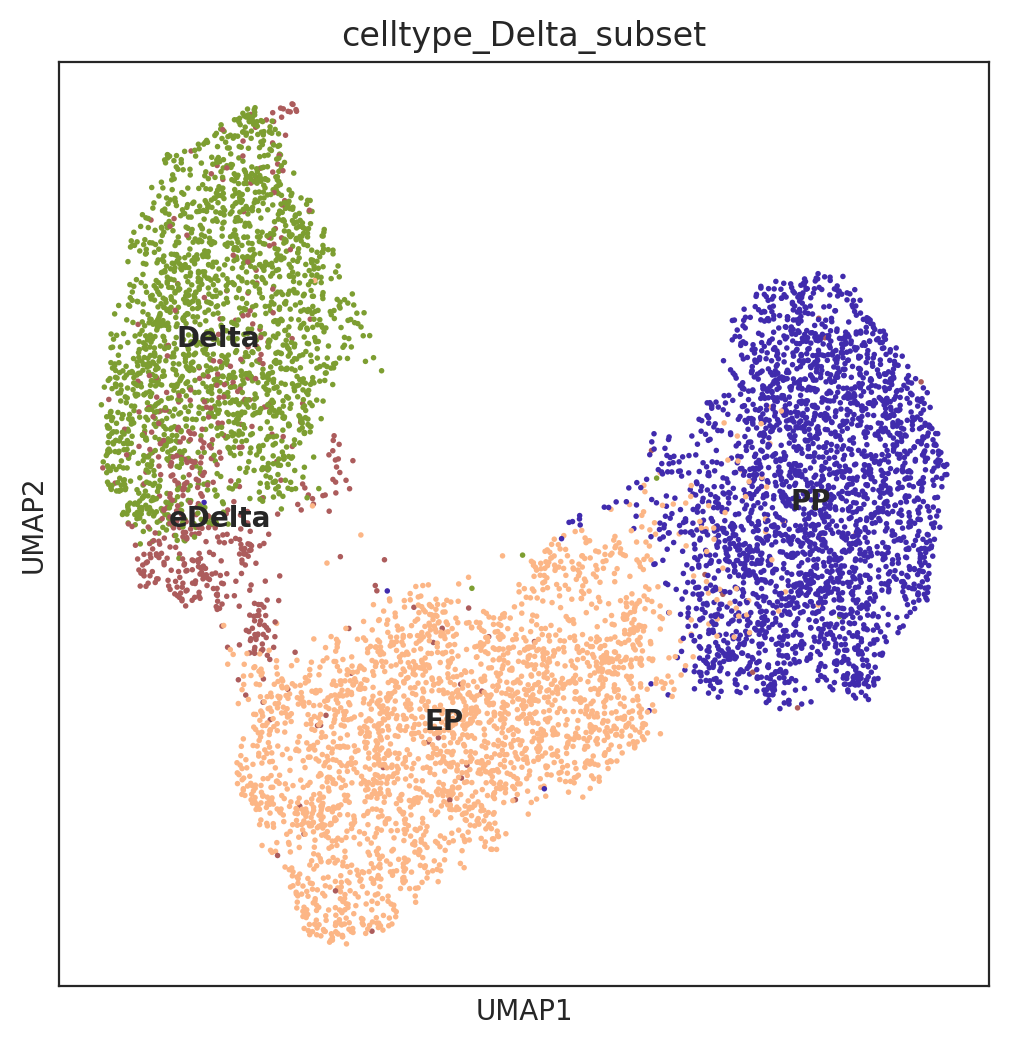

In [15]:
sc.pl.embedding(adata, basis='umap', color='celltype_Delta_subset', legend_loc='on data')

adata.obs["celltype_Delta_subset"] =adata.obs["celltype_Delta_subset"].astype("category") 

In [16]:
adata.var

""
ADGRG4
TAFA5
AC117461.1
UTY
USP9Y
...
LINC01619
ATP2B1
NTS
MGAT4C


In [17]:
pseudotime_DT_Subset_Delta = adata.obs['pseudotime_Delta_subset']
pseudotime_DT_Subset_Delta

barcode
s5d1_ACCAAGTTCCCTGGTT-1_paired               5.226267
s5d3_ATACCGGTCGGGACCT-1_paired               0.259082
s6d1_AGGACTAAGGACCTTG-1_paired              23.000321
s5d3_GATTGGTTCATGCTAA-1_paired              26.387668
s5d3_CCTATAGCAAGTCGCT-1_paired              24.179303
                                              ...    
zhu.sn.d21_TTTCGATGTGCTCTTC-1_expression     9.348169
zhu.sn.d21_TTTGACTGTCCCTCAT-1_expression     5.188366
zhu.sn.d21_TTTGATCCAACTGCTA-1_expression     6.705835
zhu.sn.d21_TTTGGTTCACAGTCGC-1_expression     9.414842
zhu.sn.d21_TTTGTTGGTCTGTGGC-1_expression    10.170718
Name: pseudotime_Delta_subset, Length: 7583, dtype: float64

In [18]:
#Prepare for Pseudotime
sc.pp.neighbors(adata, n_neighbors=10, method='umap', use_rep='X_umap')  # Adjust parameters as needed

In [19]:
sc.tl.diffmap(adata, n_comps=10)

In [20]:
# Check data in anndata
print("Metadata columns :", list(adata.obs.columns))
print("Dimensional reduction: ", list(adata.obsm.keys()))

# The AnnData should have (1) gene expression counts, 
#(2) clustering information, and (3) trajectory (dimensional reduction embedding) data.


Metadata columns : ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'modality', 'dataset', 'protocol', 'stage', 'day', 'cellsource', 'gender', '_indices', '_scvi_batch', '_scvi_labels', 'modality.1', 'dataset.1', 'protocol.1', 'stage.1', 'day.1', 'cellsource.1', 'gender.1', '_indices.1', '_scvi_batch.1', '_scvi_labels.1', 'multivi_clusters', 'cell', 'celltype_labelled_by_protocol', 'RNA_snn_res.2', 'seurat_clusters', 'RNA_snn_res.5', 'RNA_snn_res.3', 'celltype_Delta_subset', 'pseudotime_Delta_subset', 'barcode', 'UMAP_1', 'UMAP_2']
Dimensional reduction:  ['X_pca', 'X_umap', 'X_diffmap']


In [21]:
#adata.X = adata.layers["raw_count"].copy()

# Instantiate Oracle object.
oracle.import_anndata_as_raw_count(adata=adata,
                                   cluster_column_name="celltype_Delta_subset",
                                   embedding_name="X_umap")


In [22]:
#Load base-GRN data into oracle object
#You can load TF info dataframe with the following code.
oracle.import_TF_data(TF_info_matrix=base_GRN)


In [23]:
#KNN imputation

# Perform PCA
oracle.perform_PCA()


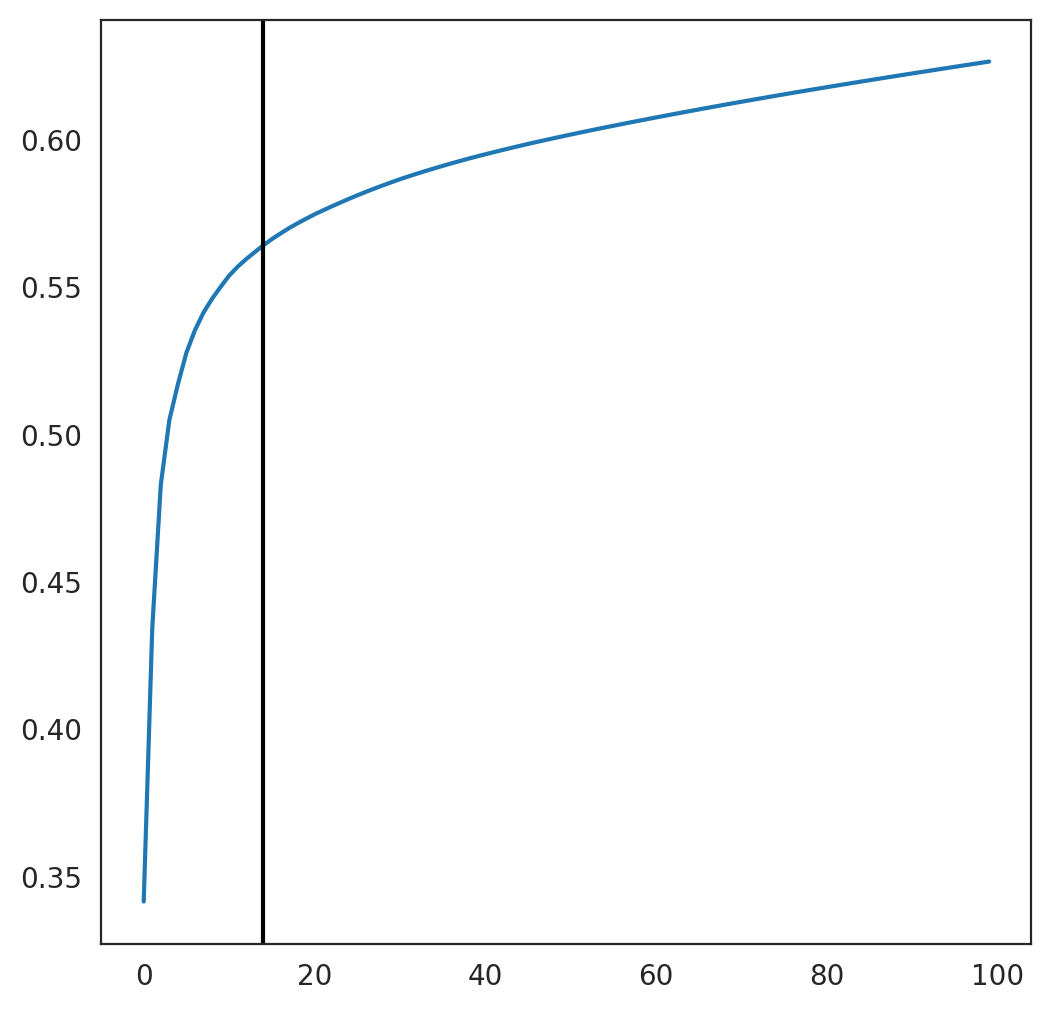

14


In [24]:
# Select important PCs
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]
plt.axvline(n_comps, c="k")
plt.show()
print(n_comps)
n_comps = min(n_comps, 50)


In [25]:
#Estimate the optimal number of nearest neighbors for KNN imputation.

n_cell = oracle.adata.shape[0]
print(f"cell number is :{n_cell}")

k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")

#KNN imputation
oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                      b_maxl=k*4, n_jobs=4)


cell number is :7583
Auto-selected k is :189


Clustering name:  celltype_Delta_subset
Cluster list ['Delta', 'EP', 'PP', 'eDelta']


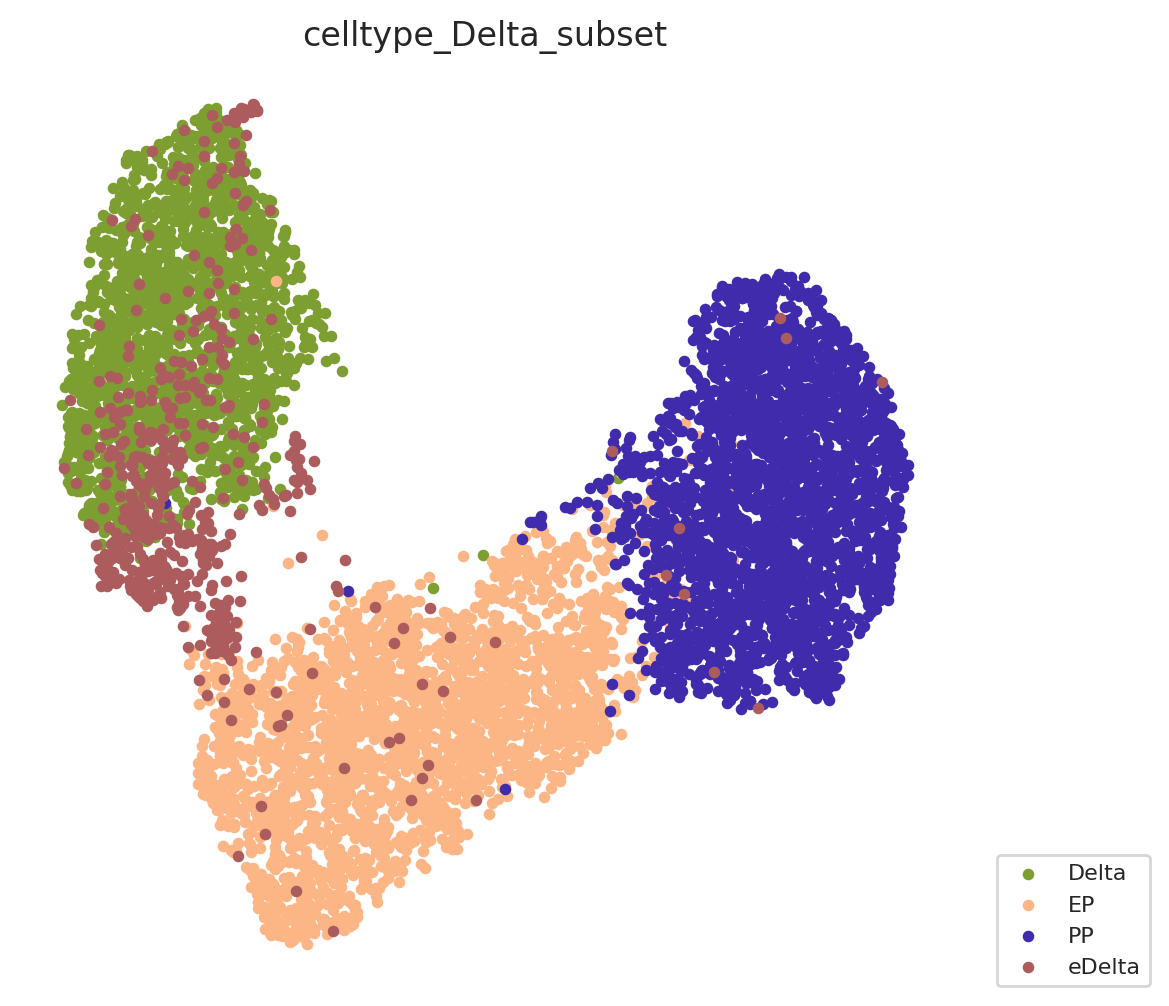

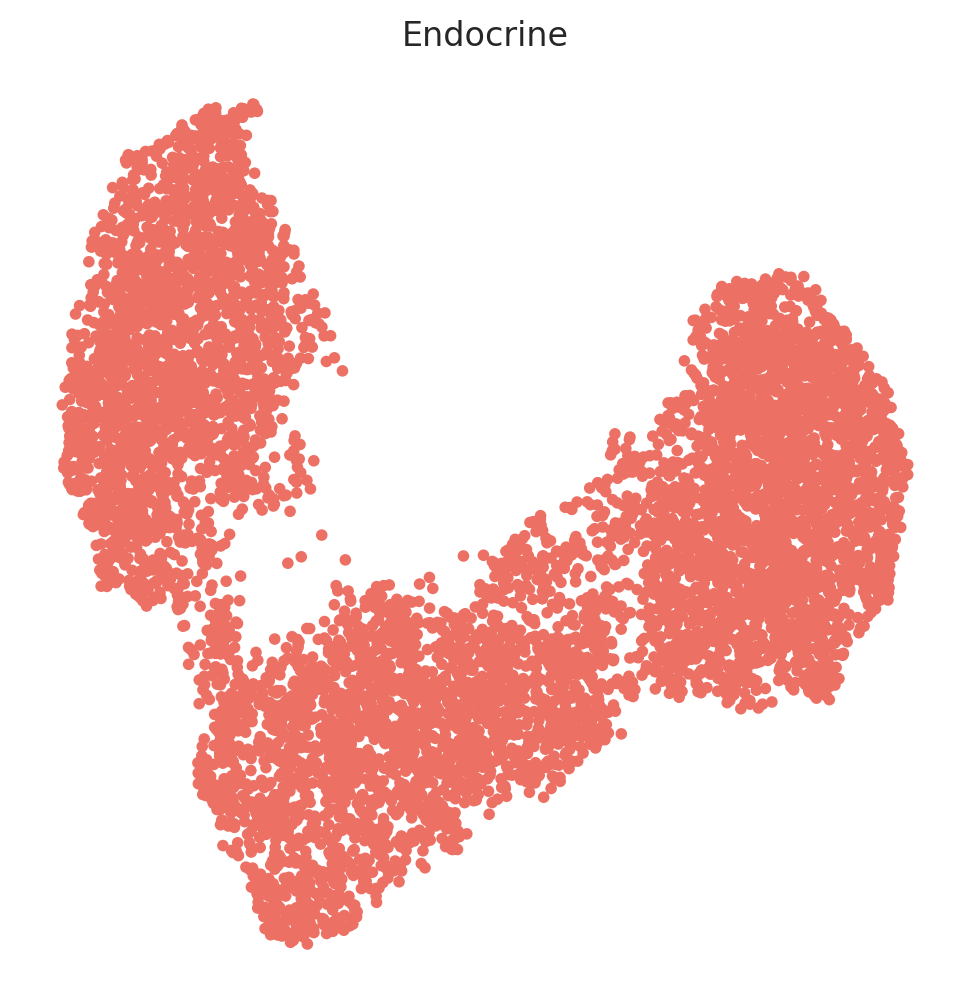

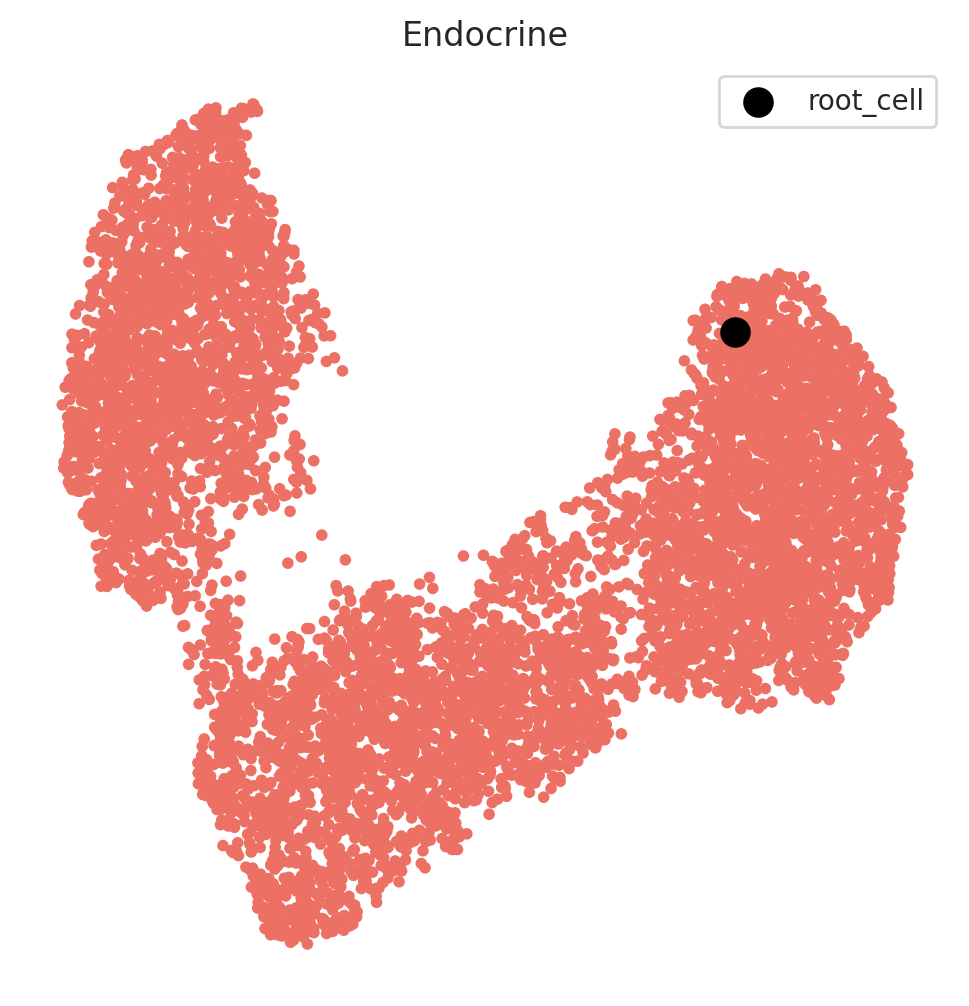

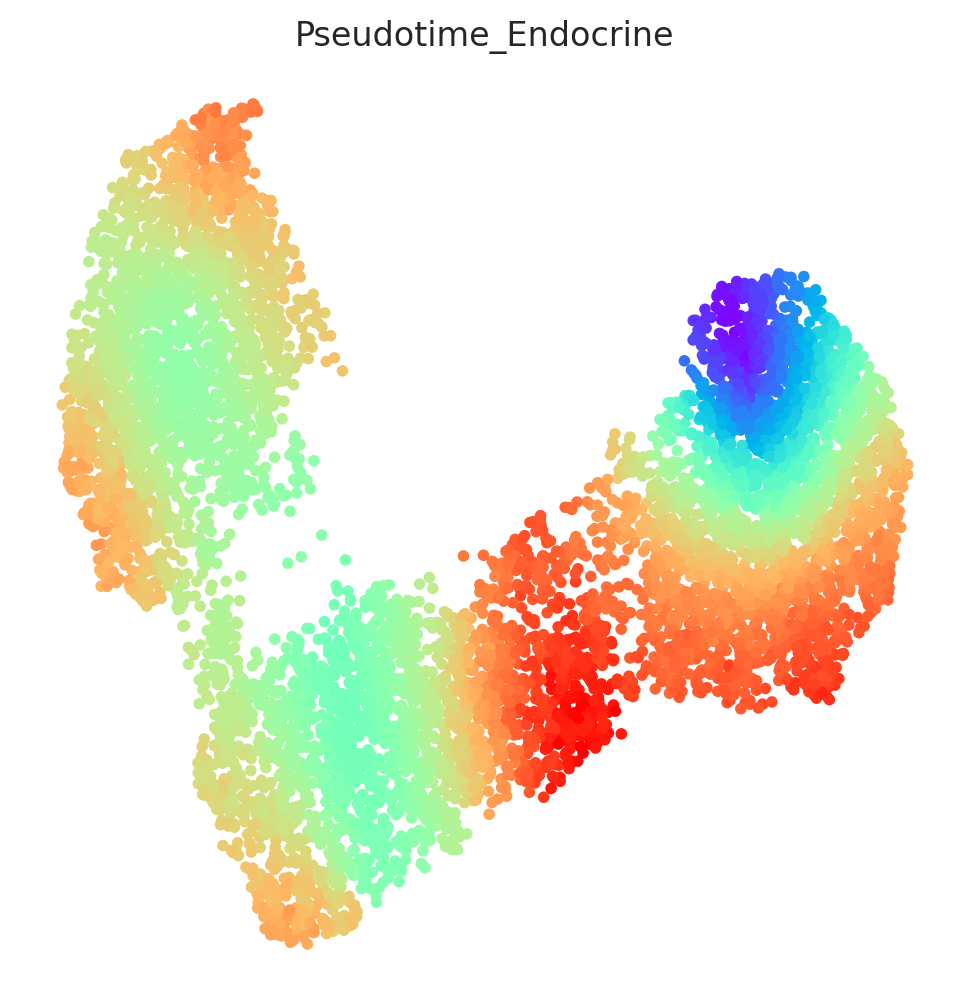

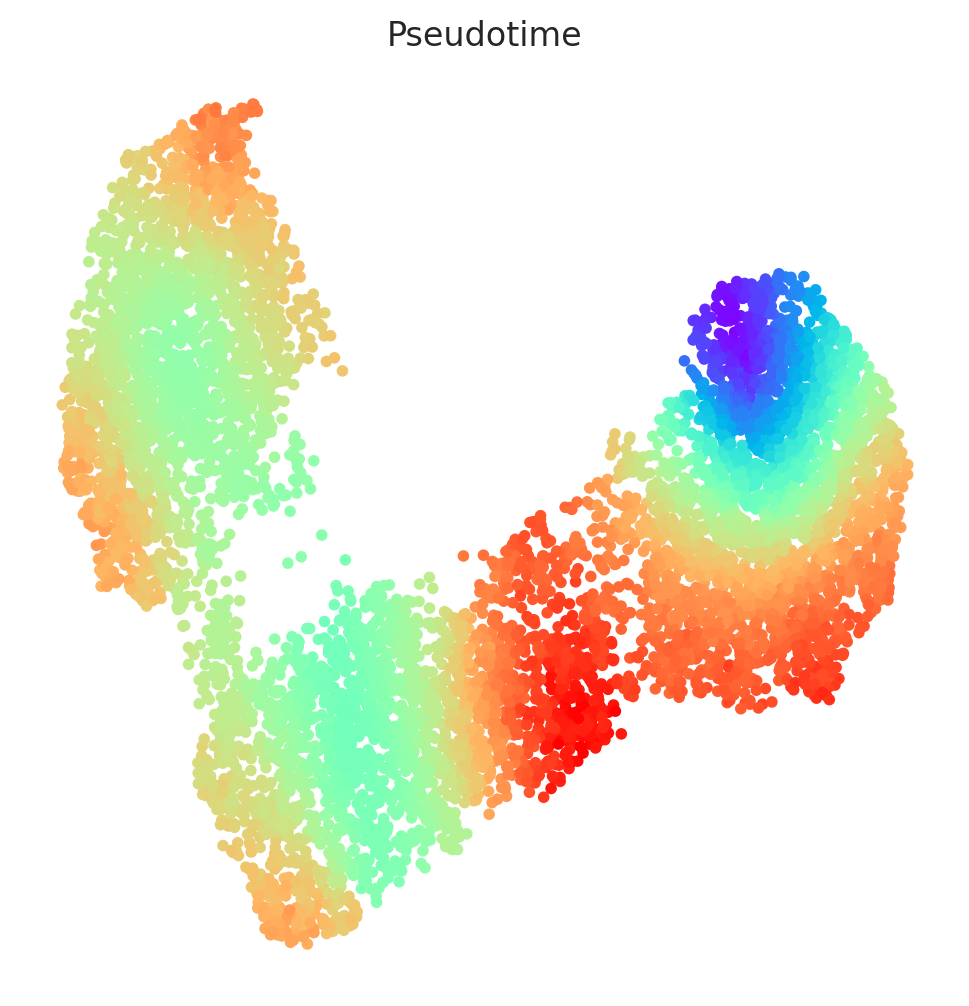

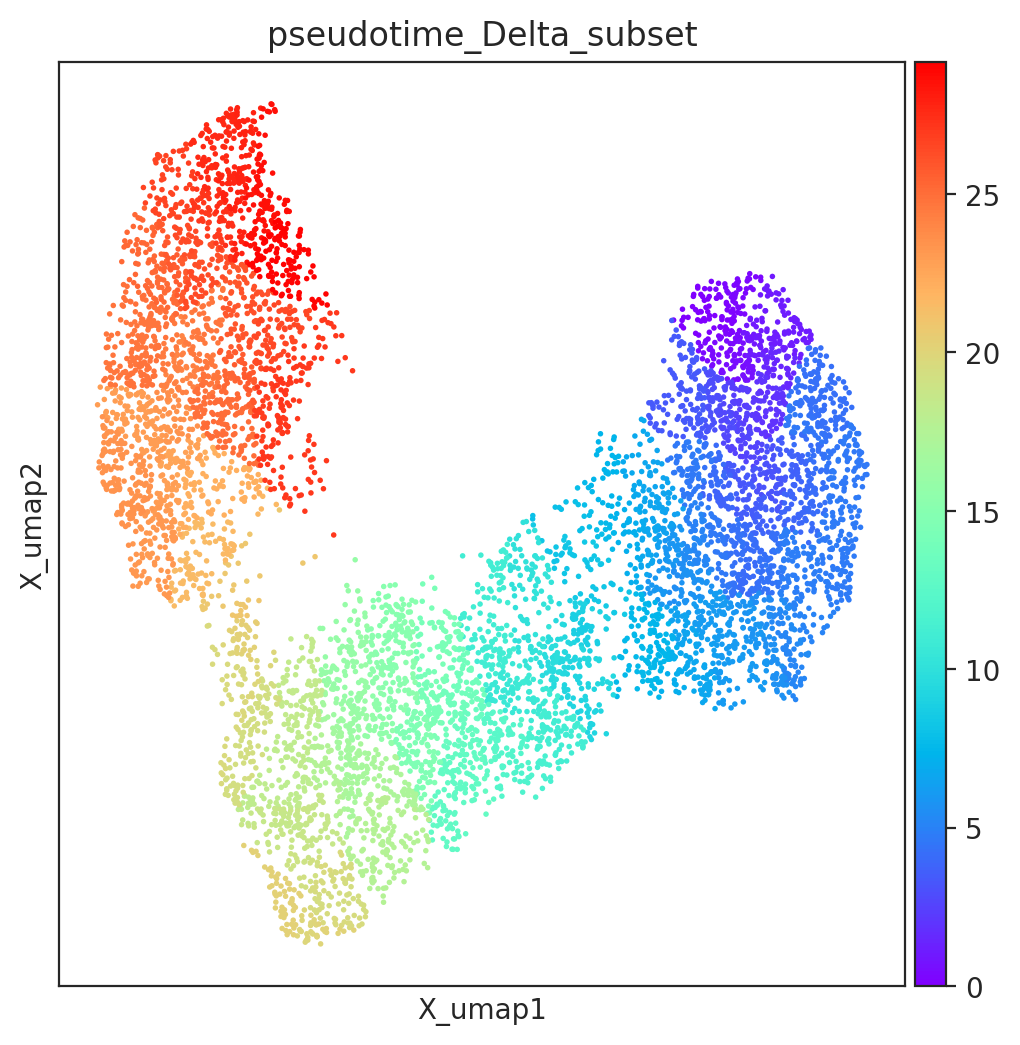

In [26]:
#Pseudotime
import celloracle as co
from celloracle.applications import Pseudotime_calculator

# Instantiate pseudotime object using oracle object.
pt = Pseudotime_calculator(oracle_object=oracle)

print("Clustering name: ", pt.cluster_column_name)
print("Cluster list", pt.cluster_list)

# Check data
pt.plot_cluster(fontsize=8)

    # Here, clusters can be classified into specific lineages
    
clusters_end_lineage = ['PP', "EP", 'eDelta','Delta']
    
    # Make a dictionary
lineage_dictionary = {"Endocrine": clusters_end_lineage}
    
    # Input lineage information into pseudotime object
pt.set_lineage(lineage_dictionary=lineage_dictionary)
    
    # Visualize lineage information
pt.plot_lineages()
    
    # Estimated root cell name for each lineage
root_cells = {"Endocrine": "veres.s4x1_x1_S4c_b1.bcHEEB_expression"}
pt.set_root_cells(root_cells=root_cells)
    # Check root cell and lineage (it has to be close to an edge)
pt.plot_root_cells()
    #"s5d5_AAACATGCAAAGCTCC-1" <- other root cell for s5d5
      
    # Calculate pseudotime
pt.get_pseudotime_per_each_lineage()
    
    # Check results
pt.plot_pseudotime(cmap="rainbow")
      
    # Add calculated pseudotime data to the oracle object
oracle.adata.obs = pt.adata.obs
      
    # Visualize pseudotime
    
fig, ax = plt.subplots(figsize=[6,6])
sc.pl.embedding(adata=oracle.adata, basis=oracle.embedding_name, 
                      ax=ax, cmap="rainbow",
                      color=["pseudotime_Delta_subset"])
      

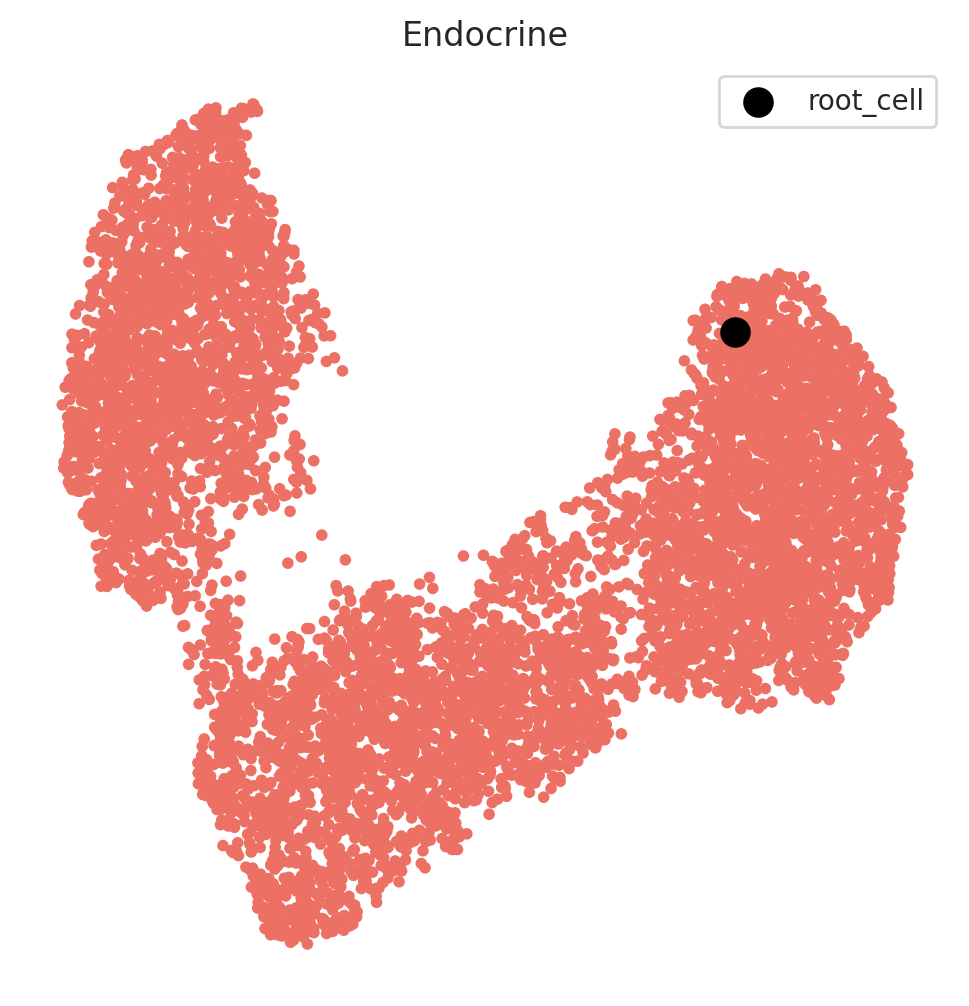

In [27]:
# Instantiate pseudotime object using oracle object.
pt = Pseudotime_calculator(oracle_object=oracle)
root_cells = {"Endocrine": "veres.s4x1_x1_S4c_b1.bcHEEB_expression"}
pt.set_root_cells(root_cells=root_cells)
pt.plot_root_cells()


In [28]:
# Save oracle object.
oracle.to_hdf5("checkpoints/celloracle/DT_Subset_Delta.celloracle.oracle")


In [15]:
# Load file.
oracle = co.load_hdf5("checkpoints/celloracle/DT_Subset_Delta.celloracle.oracle")


In [16]:
'HHEX' in oracle.adata.var_names

True

# GRN Calculations

In [31]:
#Get GRNs

#%%time
# Calculate GRN for each population in "louvain_annot" clustering unit.
# This step may take some time.(~30 minutes)
links = oracle.get_links(cluster_name_for_GRN_unit="celltype_Delta_subset", alpha=10,
                         verbose_level=10)


  0%|          | 0/4 [00:00<?, ?it/s]

Inferring GRN for Delta...


  0%|          | 0/2824 [00:00<?, ?it/s]

Inferring GRN for EP...


  0%|          | 0/2824 [00:00<?, ?it/s]

Inferring GRN for PP...


  0%|          | 0/2824 [00:00<?, ?it/s]

Inferring GRN for eDelta...


  0%|          | 0/2824 [00:00<?, ?it/s]

# Network preprocessing

In [3]:
#Filter network edges

links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)
plt.rcParams["figure.figsize"] = [9, 4.5]

links.plot_degree_distributions(plot_model=True) 
plt.rcParams["figure.figsize"] = [6, 4.5]

NameError: name 'links' is not defined

In [ ]:
# Calculate network scores and Save Links object.
links.get_network_score()
links.merged_score.tail()
links.to_hdf5(file_path="checkpoints/celloracle/DT_Subset_Delta.celloracle.links")


# Network analysis

In [3]:
# You can load files with the following command.
links = co.load_hdf5(file_path="checkpoints/celloracle/DT_Subset_Delta.celloracle.links")

In [4]:
# Check cluster name
links.cluster


['Delta', 'EP', 'PP', 'eDelta']

In [5]:
# Is HHEX present as a regulator/source in any cluster?
any('HHEX' in df['source'].values for df in links.filtered_links.values())

False

In [7]:
print("HHEX as source in links:",
      any('HHEX' in df['source'].values for df in links.links_dict.values()))

print("HHEX as target in links:",
      any('HHEX' in df['target'].values for df in links.links_dict.values()))

HHEX as source in links: False
HHEX as target in links: True


In [8]:
# Save GRN as csv
net_scores = links.merged_score
net_scores.to_csv("outputs/celloracle_tables/Network_Scores_per_Cluster_DT_Subset_Delta_paper.csv")
# Table S18

## Top Degree Centrality Fig. S21G

In [9]:
Centrality_all = pd.read_csv("outputs/celloracle_tables/Network_Scores_per_Cluster_DT_Subset_Delta_paper.csv").rename(columns={"Unnamed: 0": "gene"})
Centrality_all.head(1)


,gene,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
0,TCF12,135,0.173745,0,0.0,135,0.173745,0.0,1.0,Delta


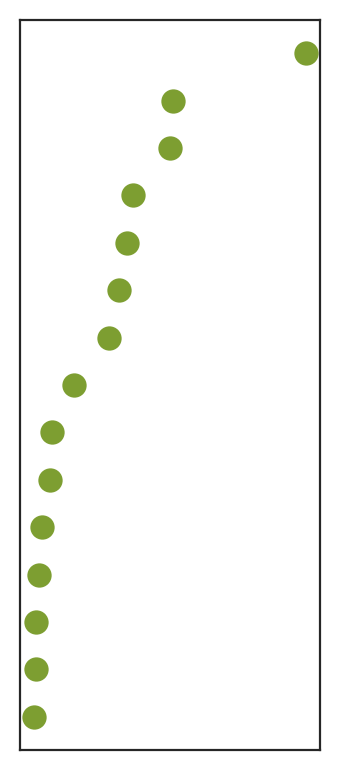

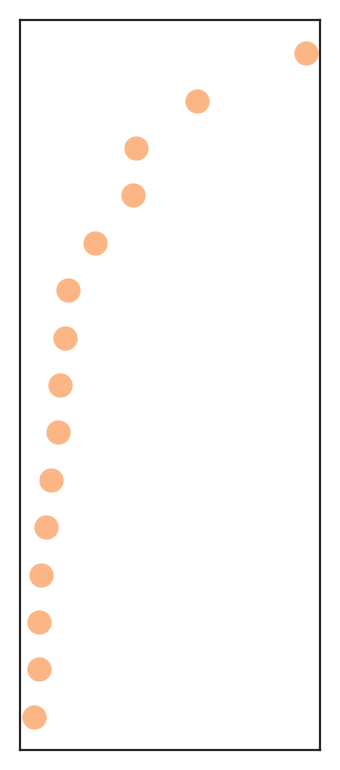

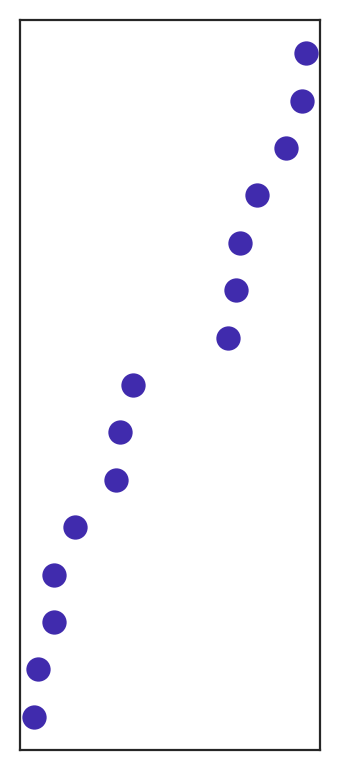

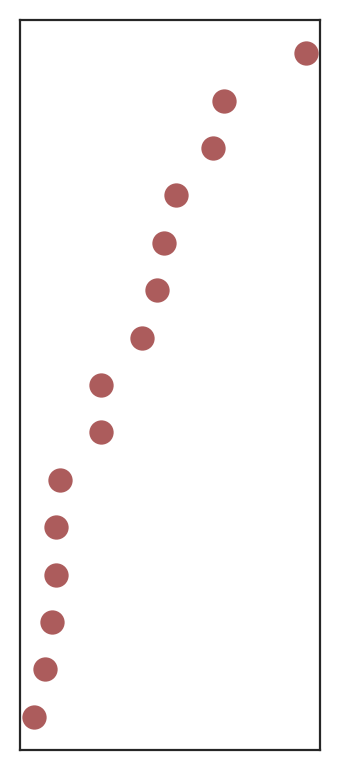

Saved clean dot plots to: outputs/celloracle_figures/DT_Subset_Delta


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- Build `top` (top 20 genes per cluster by degree_centrality_all) ---
df = Centrality_all[["gene", "degree_centrality_all", "cluster"]].copy()
df = df.dropna(subset=["gene", "degree_centrality_all", "cluster"])
df["cluster"] = df["cluster"].astype(str).str.strip()
df["gene"] = df["gene"].astype(str).str.strip()
df["degree_centrality_all"] = pd.to_numeric(df["degree_centrality_all"], errors="coerce")
df = df.dropna(subset=["degree_centrality_all"])

# If duplicates exist, keep max per (cluster,gene)
df = df.groupby(["cluster", "gene"], as_index=False)["degree_centrality_all"].max()

top_n = 15
top = (
    df.sort_values(["cluster", "degree_centrality_all"], ascending=[True, False])
      .groupby("cluster", group_keys=False)
      .head(top_n)
)

# --- Palette ---
pal = {
       "Mesench." : "#ffbd00",  # yellow
        "UE"       : "#EE3377", # magenta / raspberry
        "DE"       : "#a7defa", # light sky blue
        "GT"       : "#DDCC77", # warm sand / golden khaki
        "PP"       : "#402bad", # deep indigo
        "Exocrine" : "#117733", # forest green
        "EP"      : "#fcb686", # crema
        "lEP"      : '#cd853f', #Peru color
        "Alpha"    : "#f55e07", # vivid orange
        "eDelta"    : "#AC5C5C", #  
        "Delta"    : "#7d9e31", # olive
        "EC"       : "#015f94", # royal blue
        "Beta"     : "#ba0c2f", # WashU red
        "Beta-EC"     : "#b867bf" # purple
}

# --- Plot (dots), no labels, keep box, save tightly (no white ribbon) ---
save_folder = "outputs/celloracle_figures/DT_Subset_Delta"
os.makedirs(save_folder, exist_ok=True)

for cluster, sub in top.groupby("cluster"):
    sub = sub.sort_values("degree_centrality_all", ascending=False).reset_index(drop=True)
    sub["rank"] = sub.index + 1

    fig, ax = plt.subplots(figsize=(1.5, 3.65))
    cluster_color = pal.get(cluster, "#9e9e9e")

    ax.scatter(sub["degree_centrality_all"], sub["rank"], s=60, marker="o", c=cluster_color)
    ax.invert_yaxis()

    ax.set_title("")
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel("")

    out_png = os.path.join(save_folder, f"rank_top{top_n}_{cluster}_dots_clean.png")

    # Fill the whole canvas with the axes (box) and save with zero padding
    ax.set_position([0, 0, 1, 1])
    fig.savefig(out_png, dpi=600, bbox_inches="tight", pad_inches=0)

    plt.show()
    plt.close(fig)

print(f"Saved clean dot plots to: {save_folder}")


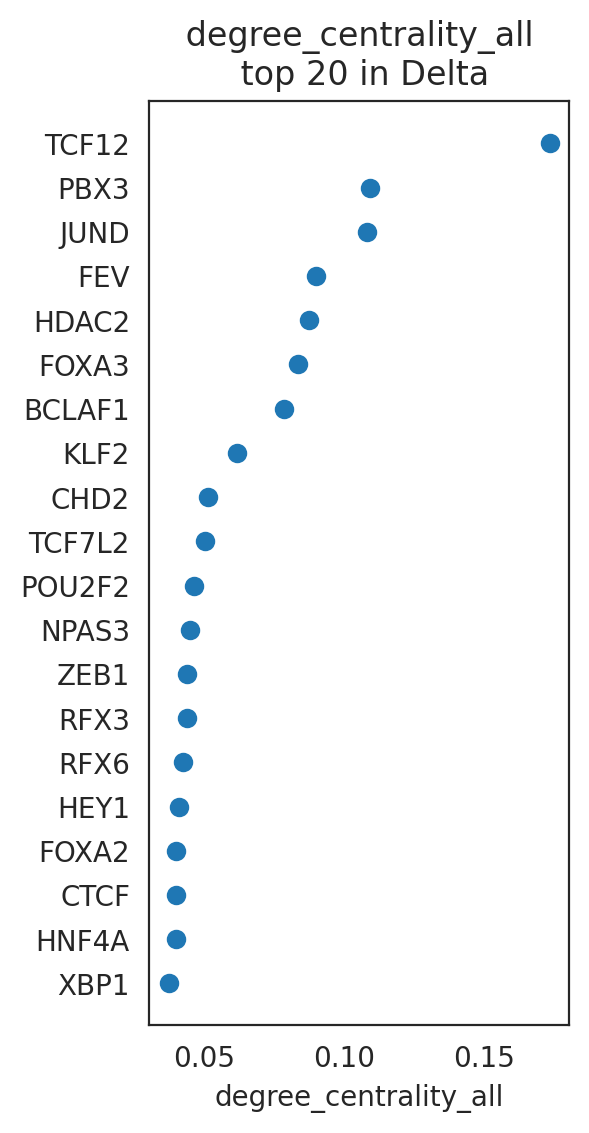

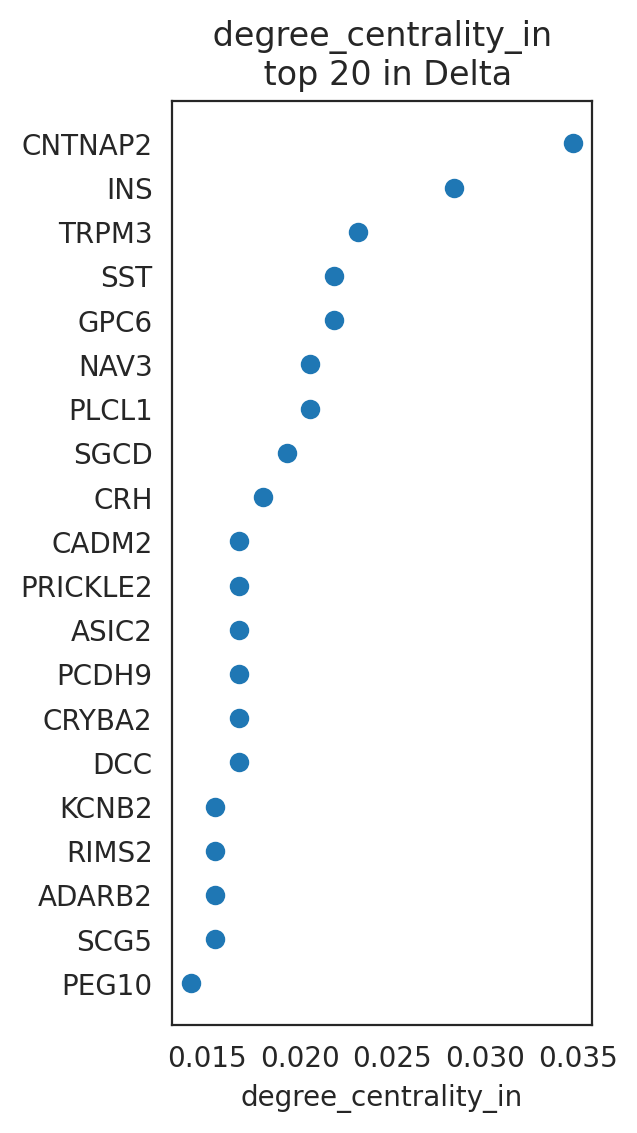

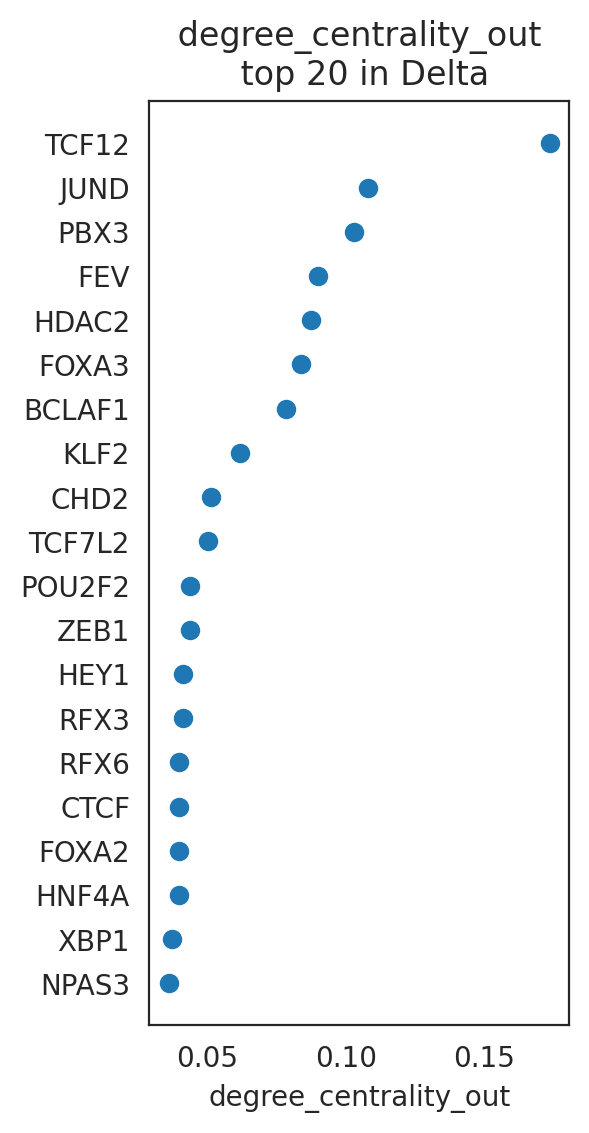

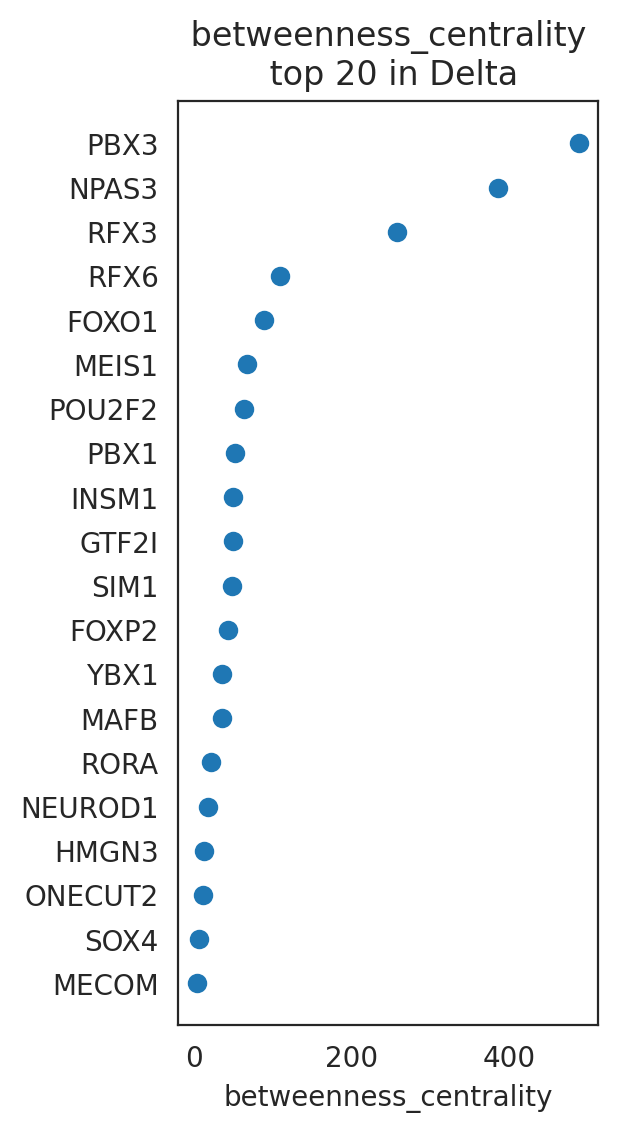

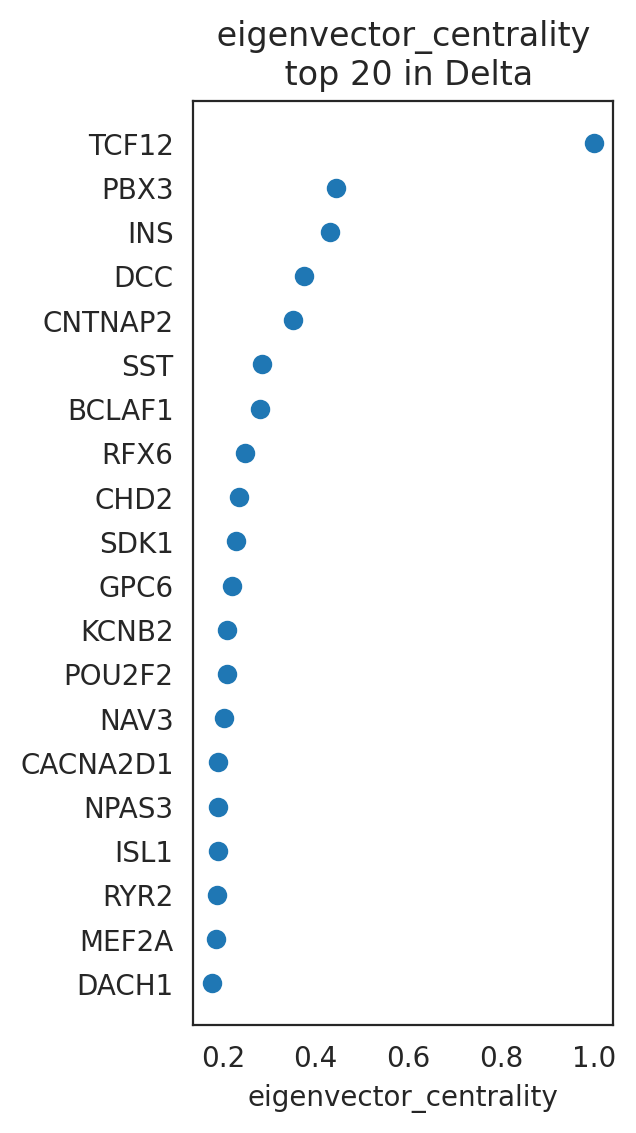

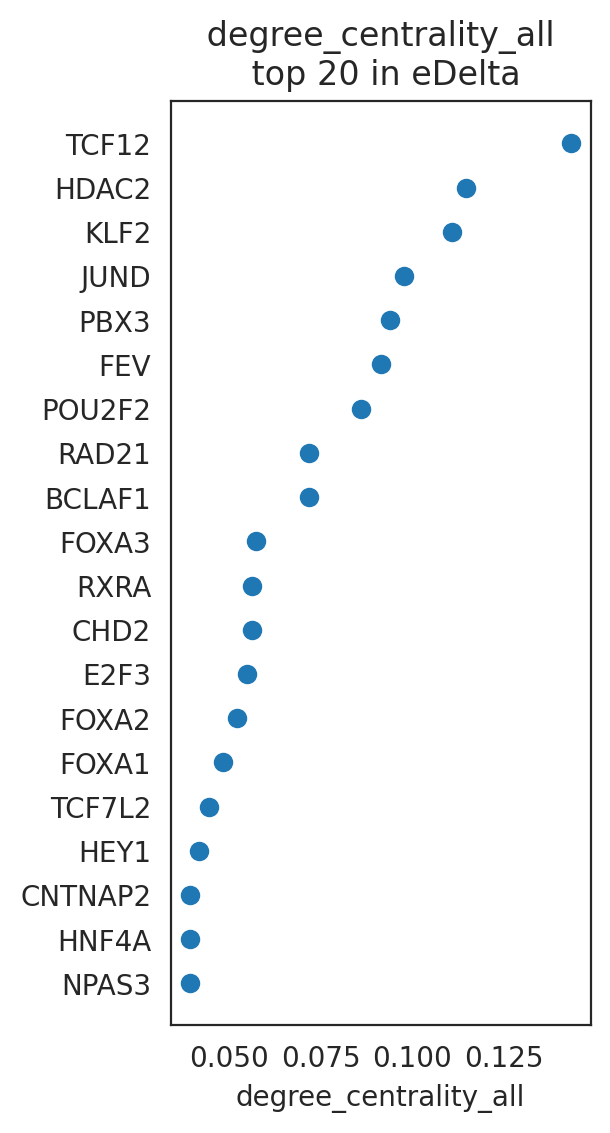

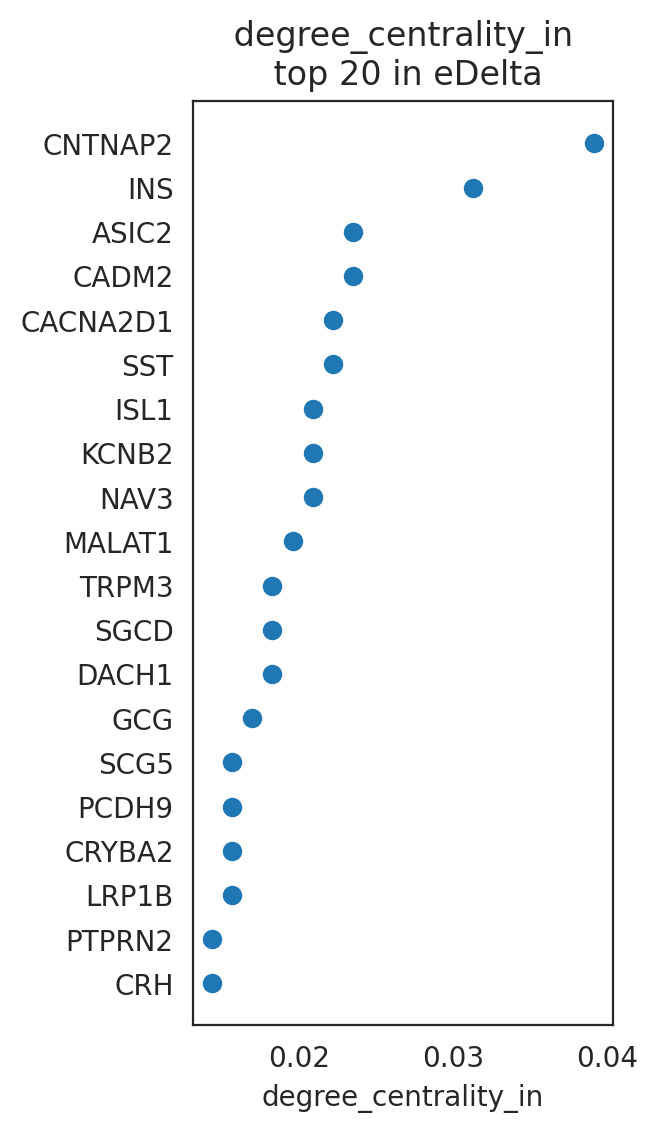

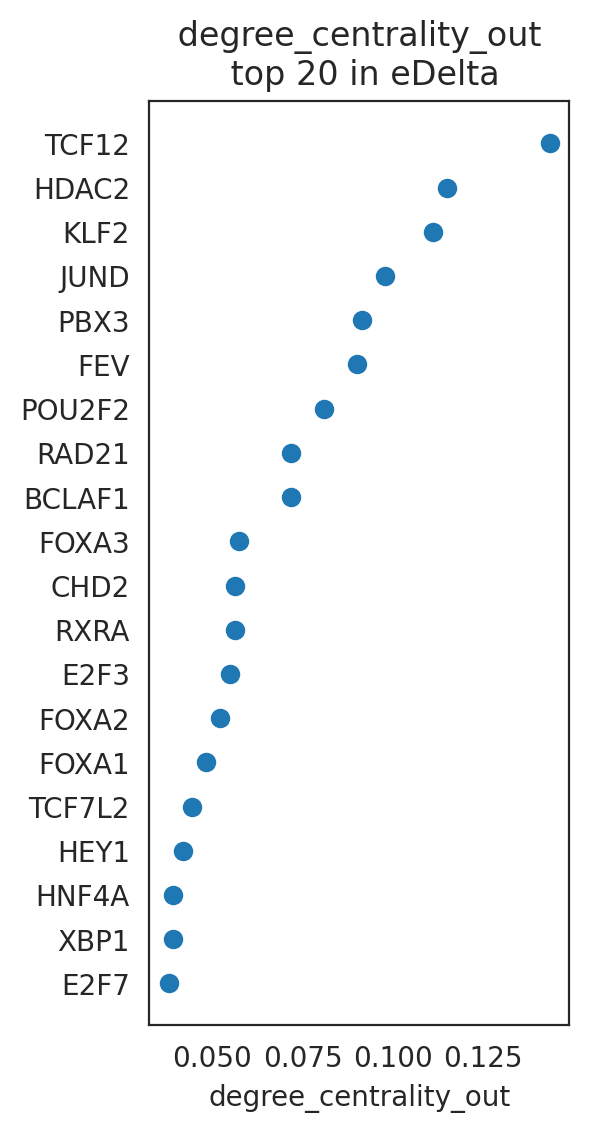

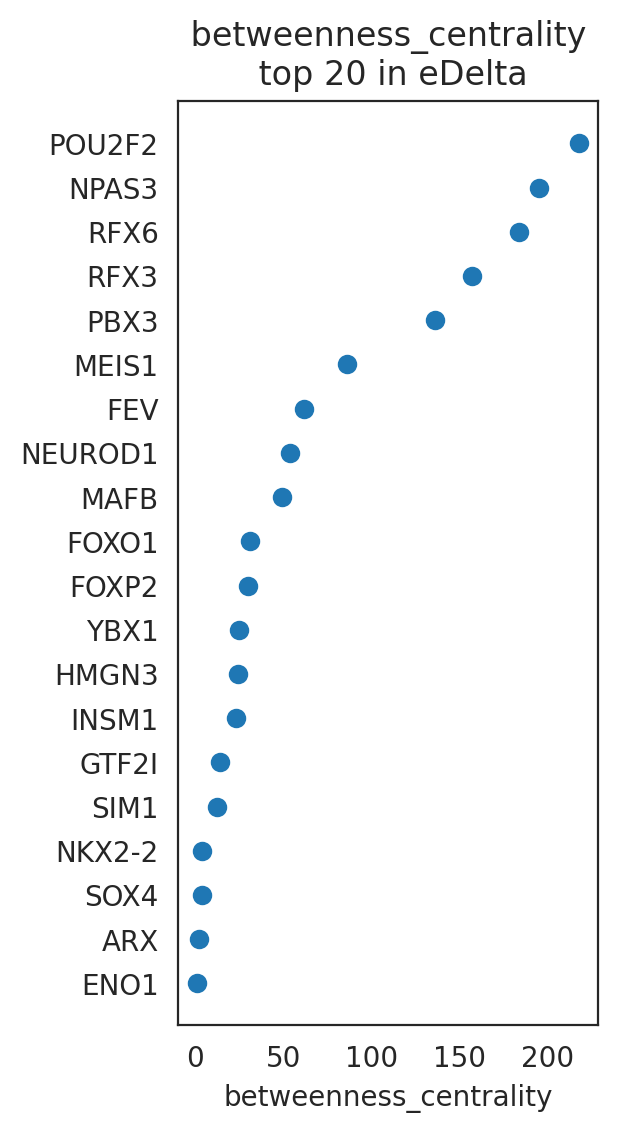

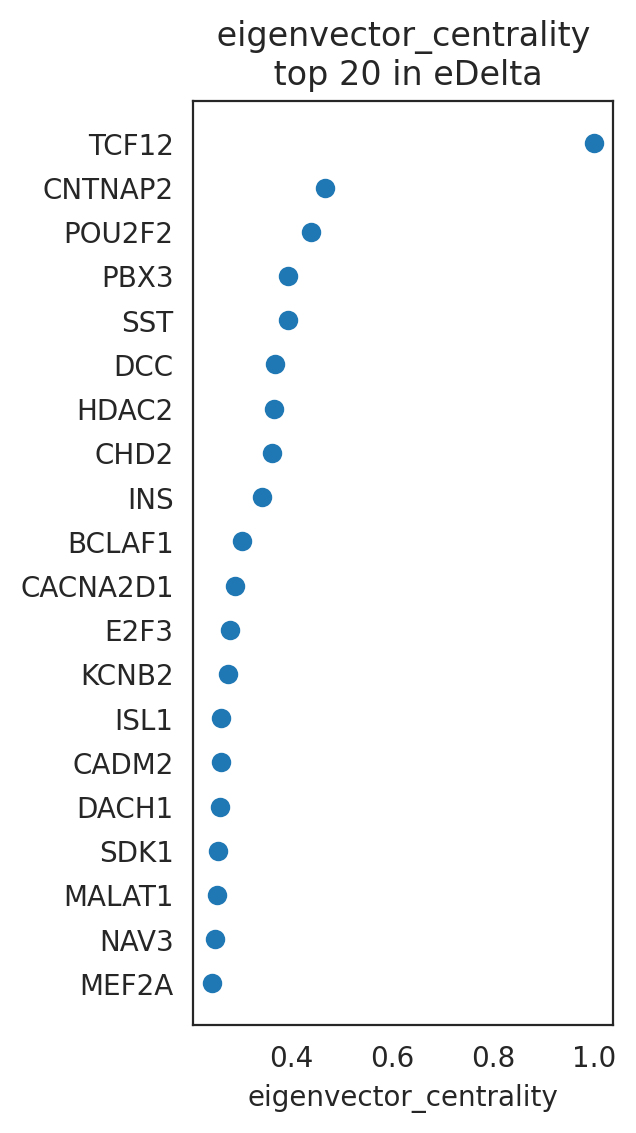

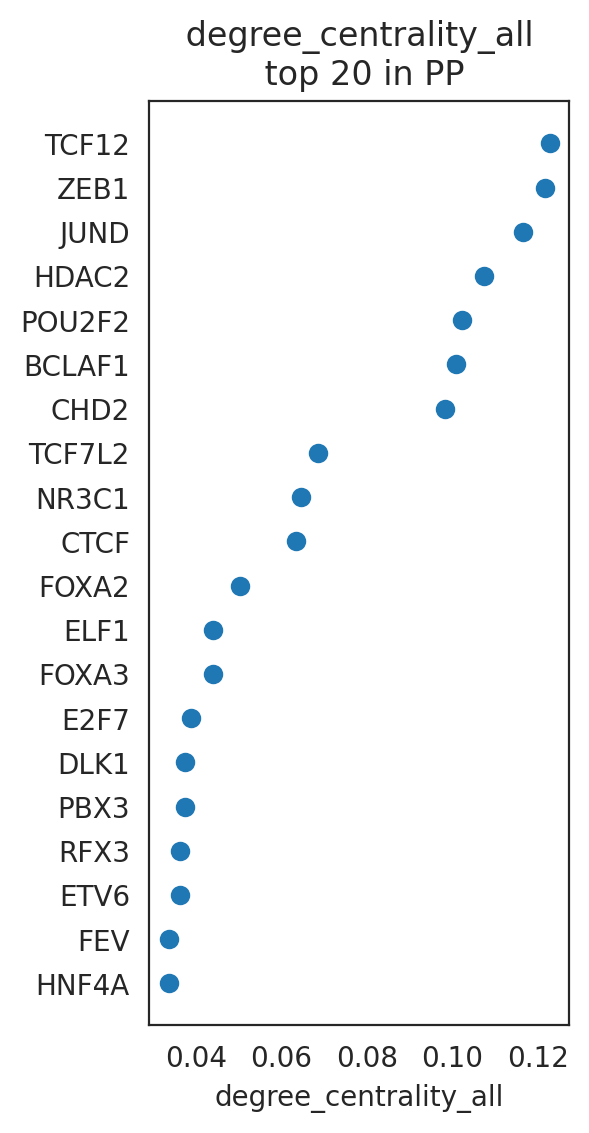

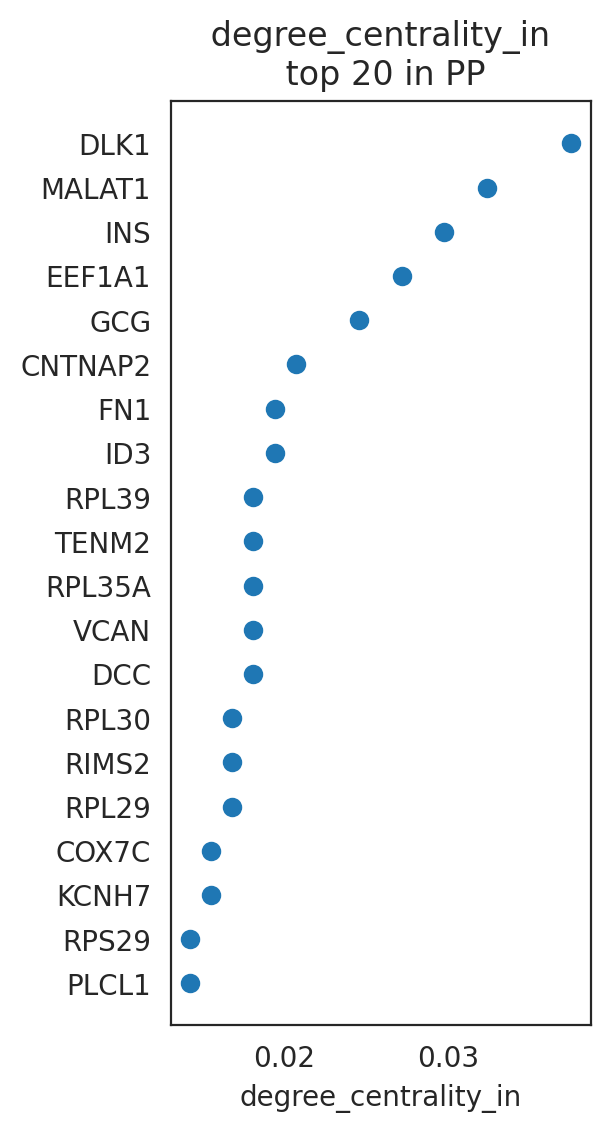

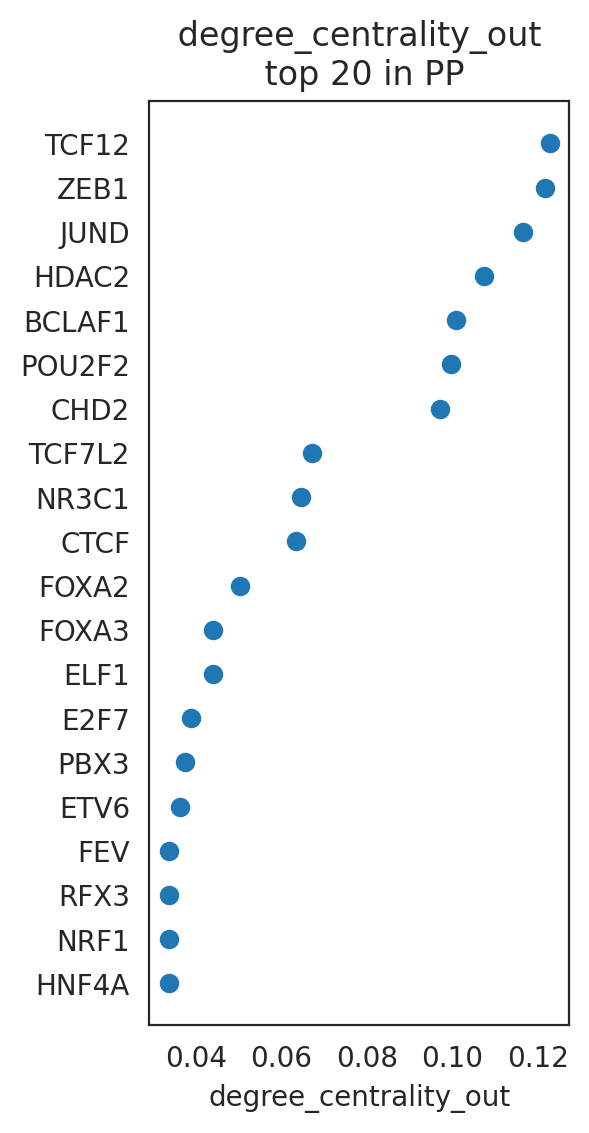

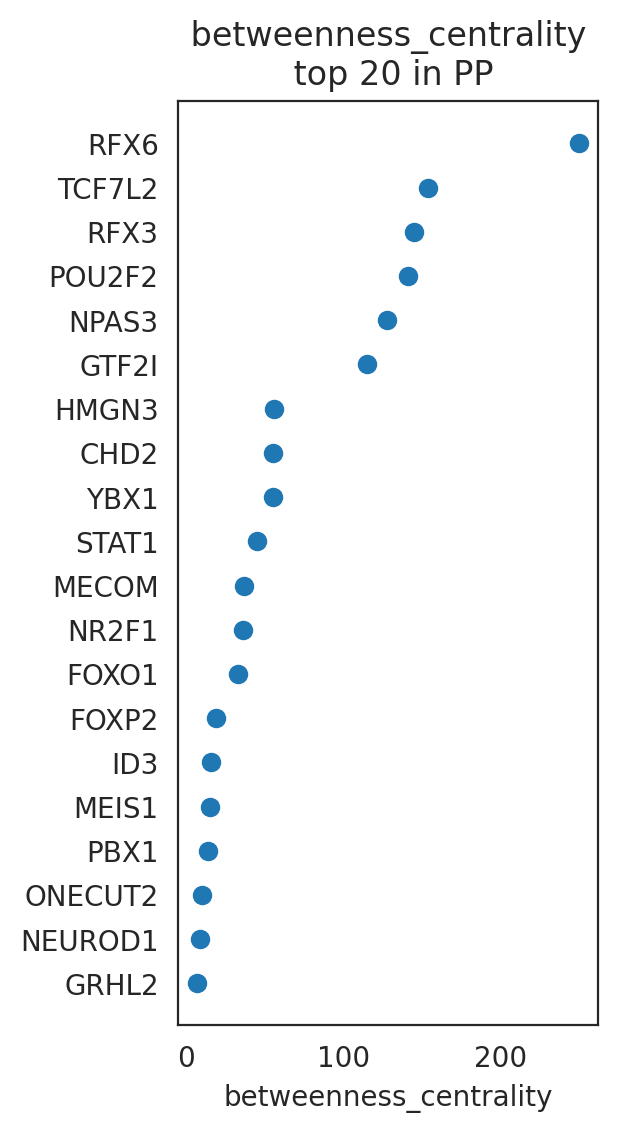

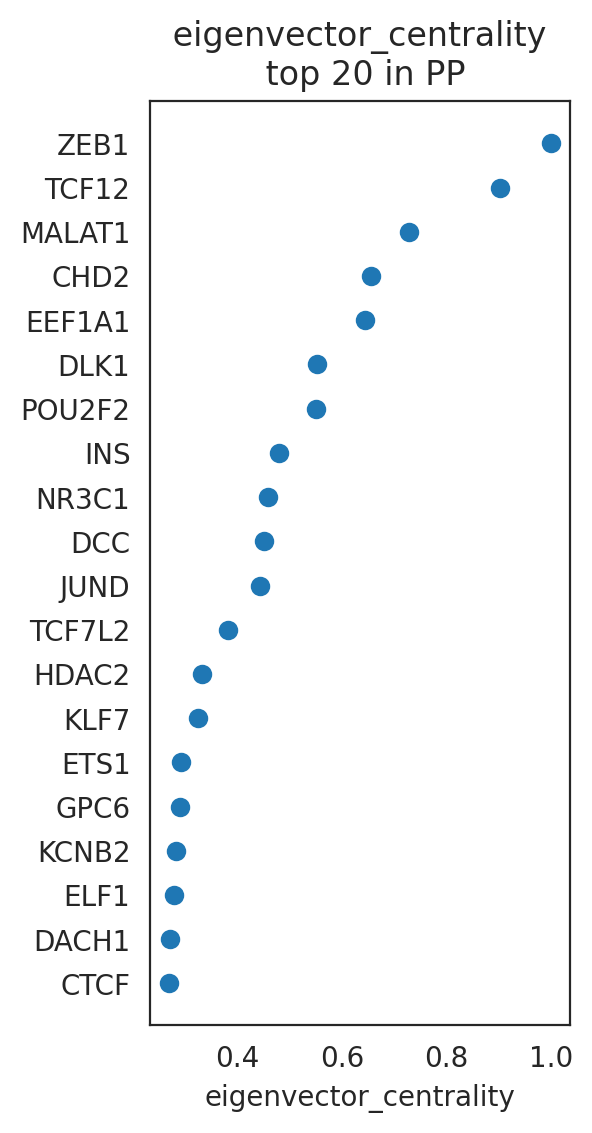

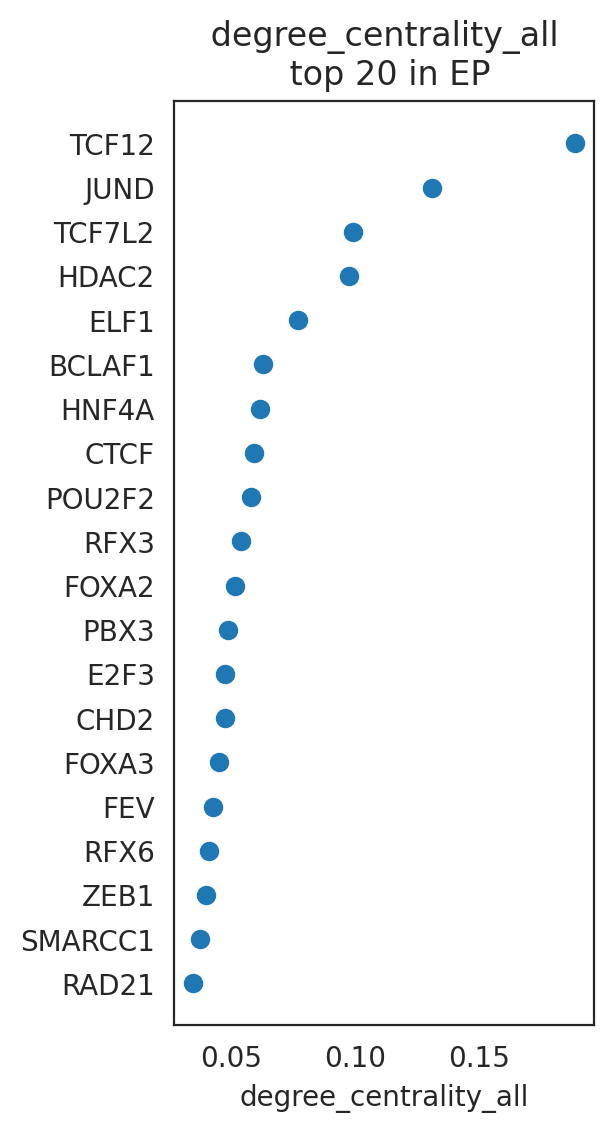

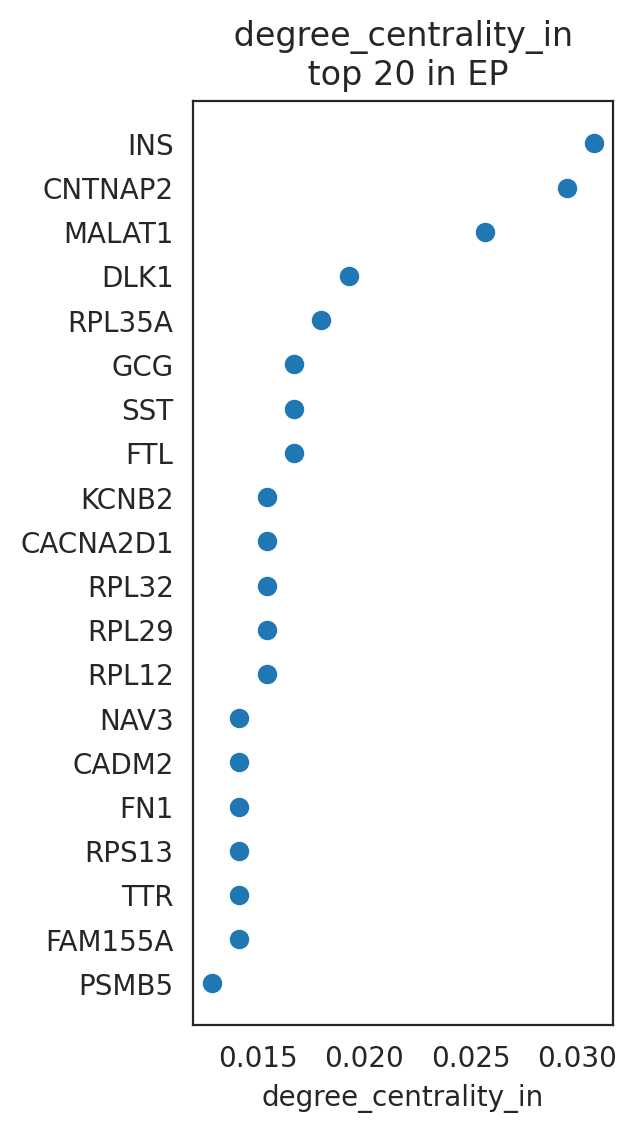

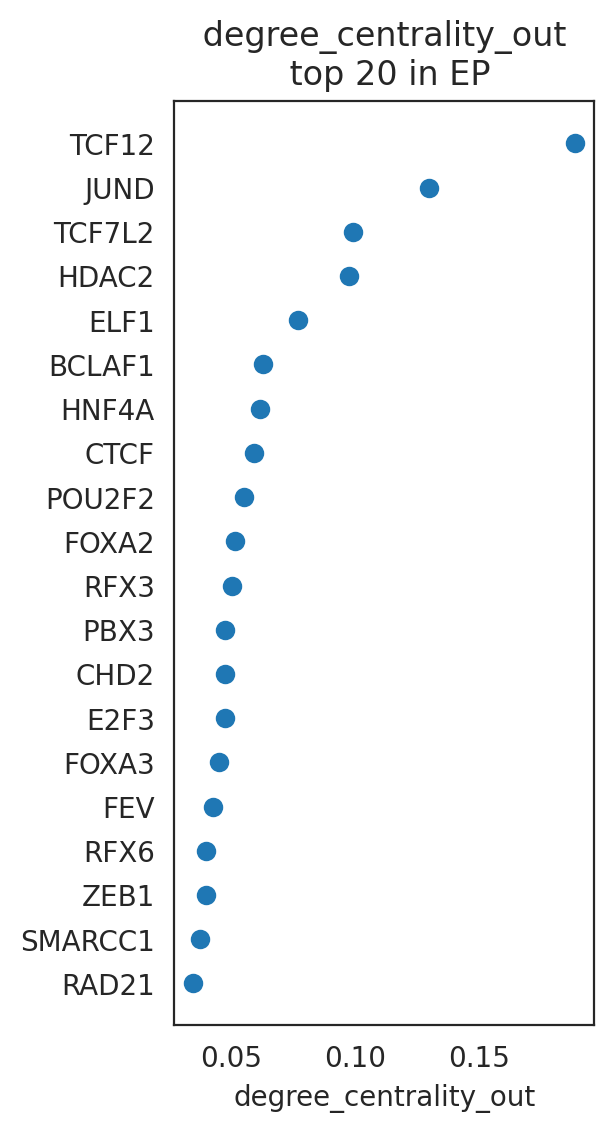

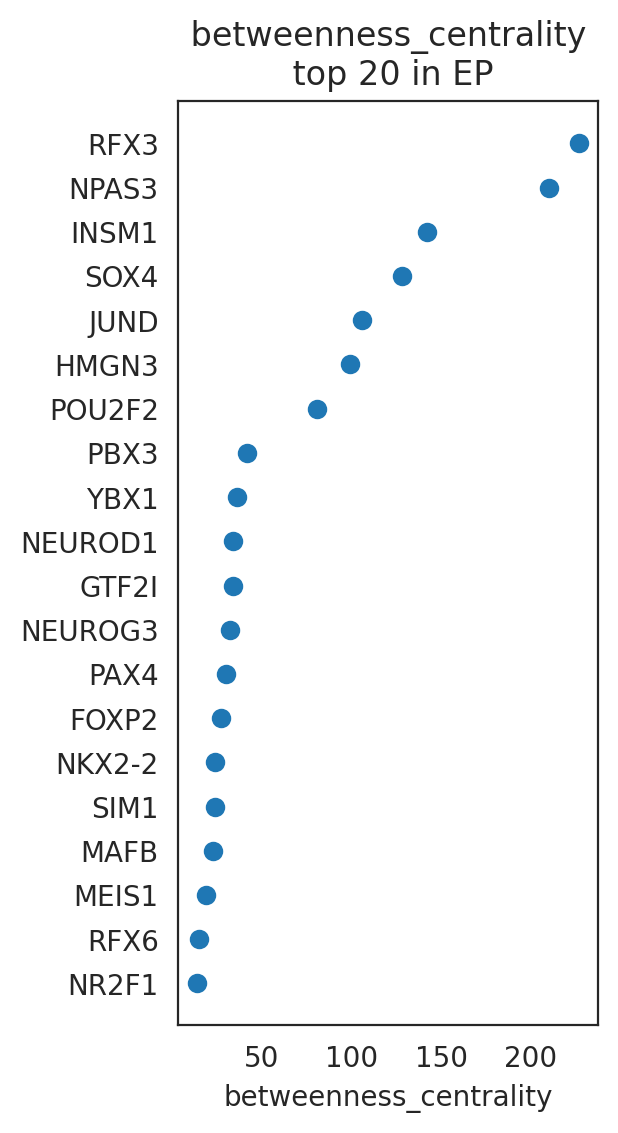

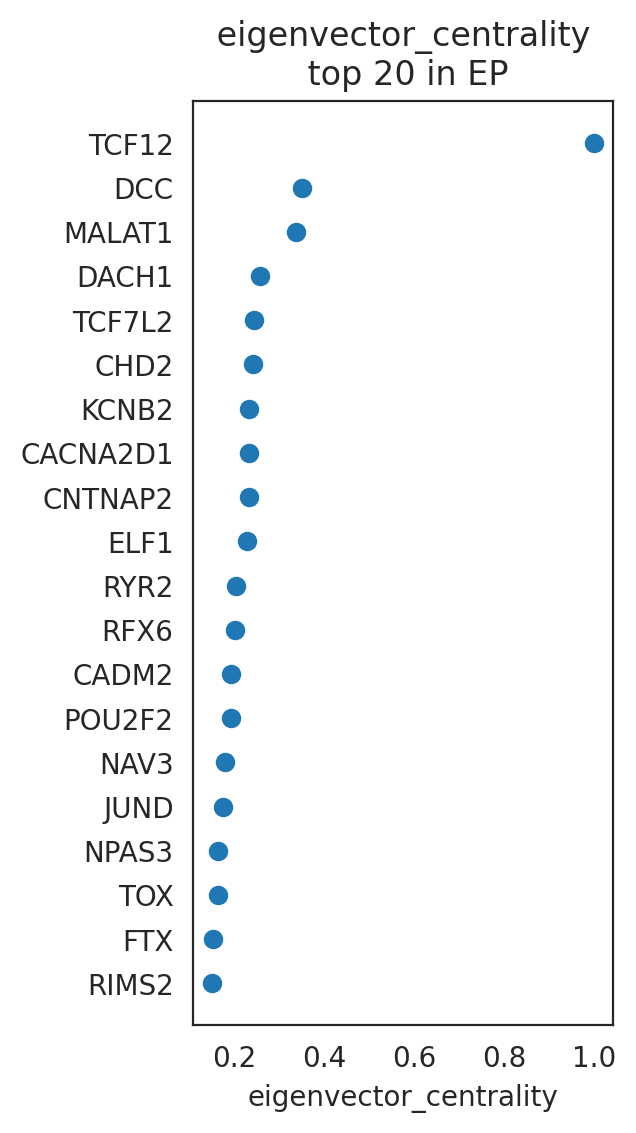

In [39]:
# Visualize top n-th genes with high scores.
plt.rcParams["figure.figsize"] = [6, 6]
links.plot_scores_as_rank(cluster="Delta", 
                          n_gene=20, save=f"{save_folder}/DT_Subset_Delta")
links.plot_scores_as_rank(cluster="eDelta", 
                          n_gene=20, save=f"{save_folder}/DT_Subset_Delta")
links.plot_scores_as_rank(cluster="PP", 
                          n_gene=20, save=f"{save_folder}/DT_Subset_Delta")
links.plot_scores_as_rank(cluster="EP", 
                          n_gene=20, save=f"{save_folder}/DT_Subset_Delta")

## Degree Centrality per gene

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_gene_centrality_across_clusters_equal_air(
    df, gene_of_interest, pal,
    cluster_order=None,
    save_folder="outputs/celloracle_figures/DT_Subset_Delta",
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
):
    os.makedirs(save_folder, exist_ok=True)

    g = df[df["gene"] == gene_of_interest].copy()
    if g.empty:
        raise ValueError(f"{gene_of_interest} not found (check spelling/case).")

    # enforce custom order (e.g. DE, GT, PP)
    if cluster_order is not None:
        order_map = {c: i for i, c in enumerate(cluster_order)}
        g["order"] = g["cluster"].map(order_map).fillna(len(order_map) + 999).astype(int)
        g = g.sort_values(["order", "cluster"]).reset_index(drop=True)
    else:
        g = g.sort_values("degree_centrality_all", ascending=False).reset_index(drop=True)

    n = g.shape[0]

    # (Optional but usually nicer when swapping axes): make width scale with n, keep height fixed-ish
    height_in = width_in
    width_in = max(row_height_in * n, 0.03)

    # Dot diameter fixed at 0.1"
    D_pts = dot_diameter_in * 72.0
    s = np.pi * (D_pts / 2.0) ** 2  # area in pt^2

    x = np.arange(n)  # cluster index on X
    y = g["degree_centrality_all"].values  # centrality on Y
    colors = g["cluster"].map(pal).fillna("#9e9e9e").values

    fig, ax = plt.subplots(figsize=(width_in, height_in), dpi=dpi)

    # ---- SWAP: (x,y) becomes (index, centrality) ----
    ax.scatter(x, y, s=s, marker="o", c=colors)

    # Minimal axes (keep box)
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Make the axes fill the figure so there's no ribbon
    ax.set_position([0, 0, 1, 1])

    # Base limits (before adding inch-based padding)
    ymin = float(np.min(y))
    ymax = float(np.max(y))
    if ymax == ymin:
        ymax = ymin + 1e-6

    # ---- PRINT min/max for PPT ----
    print(f"{gene_of_interest} degree_centrality_all min = {ymin:.6g}")
    print(f"{gene_of_interest} degree_centrality_all max = {ymax:.6g}")

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(ymin, ymax)

    # --- Compute EXACT padding in data units for equal air in inches ---
    clear_in = (dot_diameter_in / 2.0) + air_in   # 0.05" + 0.01" = 0.06"
    clear_px = clear_in * dpi

    fig.canvas.draw()  # ensure transforms are ready

    # x padding in data units (at mid y)
    y_mid = (ymin + ymax) / 2
    p0 = ax.transData.transform((-0.5, y_mid))
    x1, _ = ax.transData.inverted().transform((p0[0] + clear_px, p0[1]))
    pad_x = x1 - (-0.5)

    # y padding in data units (at mid x)
    x_mid = (n - 1) / 2 if n > 1 else 0
    p0y = ax.transData.transform((x_mid, ymin))
    _, y1 = ax.transData.inverted().transform((p0y[0], p0y[1] + clear_px))
    pad_y = y1 - ymin

    ax.set_xlim(-0.001 - pad_x, (n - 0.999) + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    out_png = os.path.join(save_folder, f"{gene_of_interest}_degree_centrality_all.png")
    fig.savefig(out_png, dpi=dpi, pad_inches=0)  # keep symmetry

    plt.show()
    plt.close(fig)

    # Return path 
    return out_png


In [ ]:
# Example
out = plot_gene_centrality_across_clusters_equal_air(
    df=df,
    gene_of_interest="ZEB1",
    pal=pal,
    cluster_order=["PP", "EP",'eDelta_1', "eDelta_2", "Delta"],
    width_in=0.9,
    row_height_in=0.15,
    dot_diameter_in=0.1,
    air_in=0.03,
    dpi=600
)
print("Saved:", out)

## TFs Ranked coef

In [11]:
import os
import pandas as pd

# Combine all clusters into one table
all_targets_list = []

for cluster_name, cluster_df in links.filtered_links.items():
    temp = cluster_df.copy()
    temp["cell_state"] = cluster_name
    all_targets_list.append(temp)

all_targets_df = pd.concat(all_targets_list, ignore_index=True)

# Keep only the columns you want, if they exist
cols_to_keep = ["cell_state", "source", "target", "coef_mean", "coef_abs"]
cols_to_keep = [c for c in cols_to_keep if c in all_targets_df.columns]

all_targets_df = all_targets_df[cols_to_keep]

# Rename for clarity
all_targets_df = all_targets_df.rename(columns={
    "source": "TF",
    "target": "Target",
    "coef_mean": "Coefficient",
    "coef_abs": "Abs_Coefficient"
})

# Optional: sort nicely
all_targets_df = all_targets_df.sort_values(
    by=["cell_state", "TF", "Abs_Coefficient"],
    ascending=[True, True, False]
).reset_index(drop=True)

# Preview
print(all_targets_df.head())

# Save
output_dir = "outputs/celloracle_tables/DT_Subset_Delta"
os.makedirs(output_dir, exist_ok=True)

all_targets_df.to_csv(
    os.path.join(output_dir, "All_TFs_all_targets_all_coefficients.csv"),
    index=False
)
# Table S21

  cell_state   TF     Target  Coefficient  Abs_Coefficient
0      Delta  AHR     CRYBA2     0.289026         0.289026
1      Delta  AHR        CRH    -0.278205         0.278205
2      Delta  AHR  LINC02197     0.207463         0.207463
3      Delta  AHR     RNF150     0.194873         0.194873
4      Delta  AHR      SGPL1     0.171544         0.171544


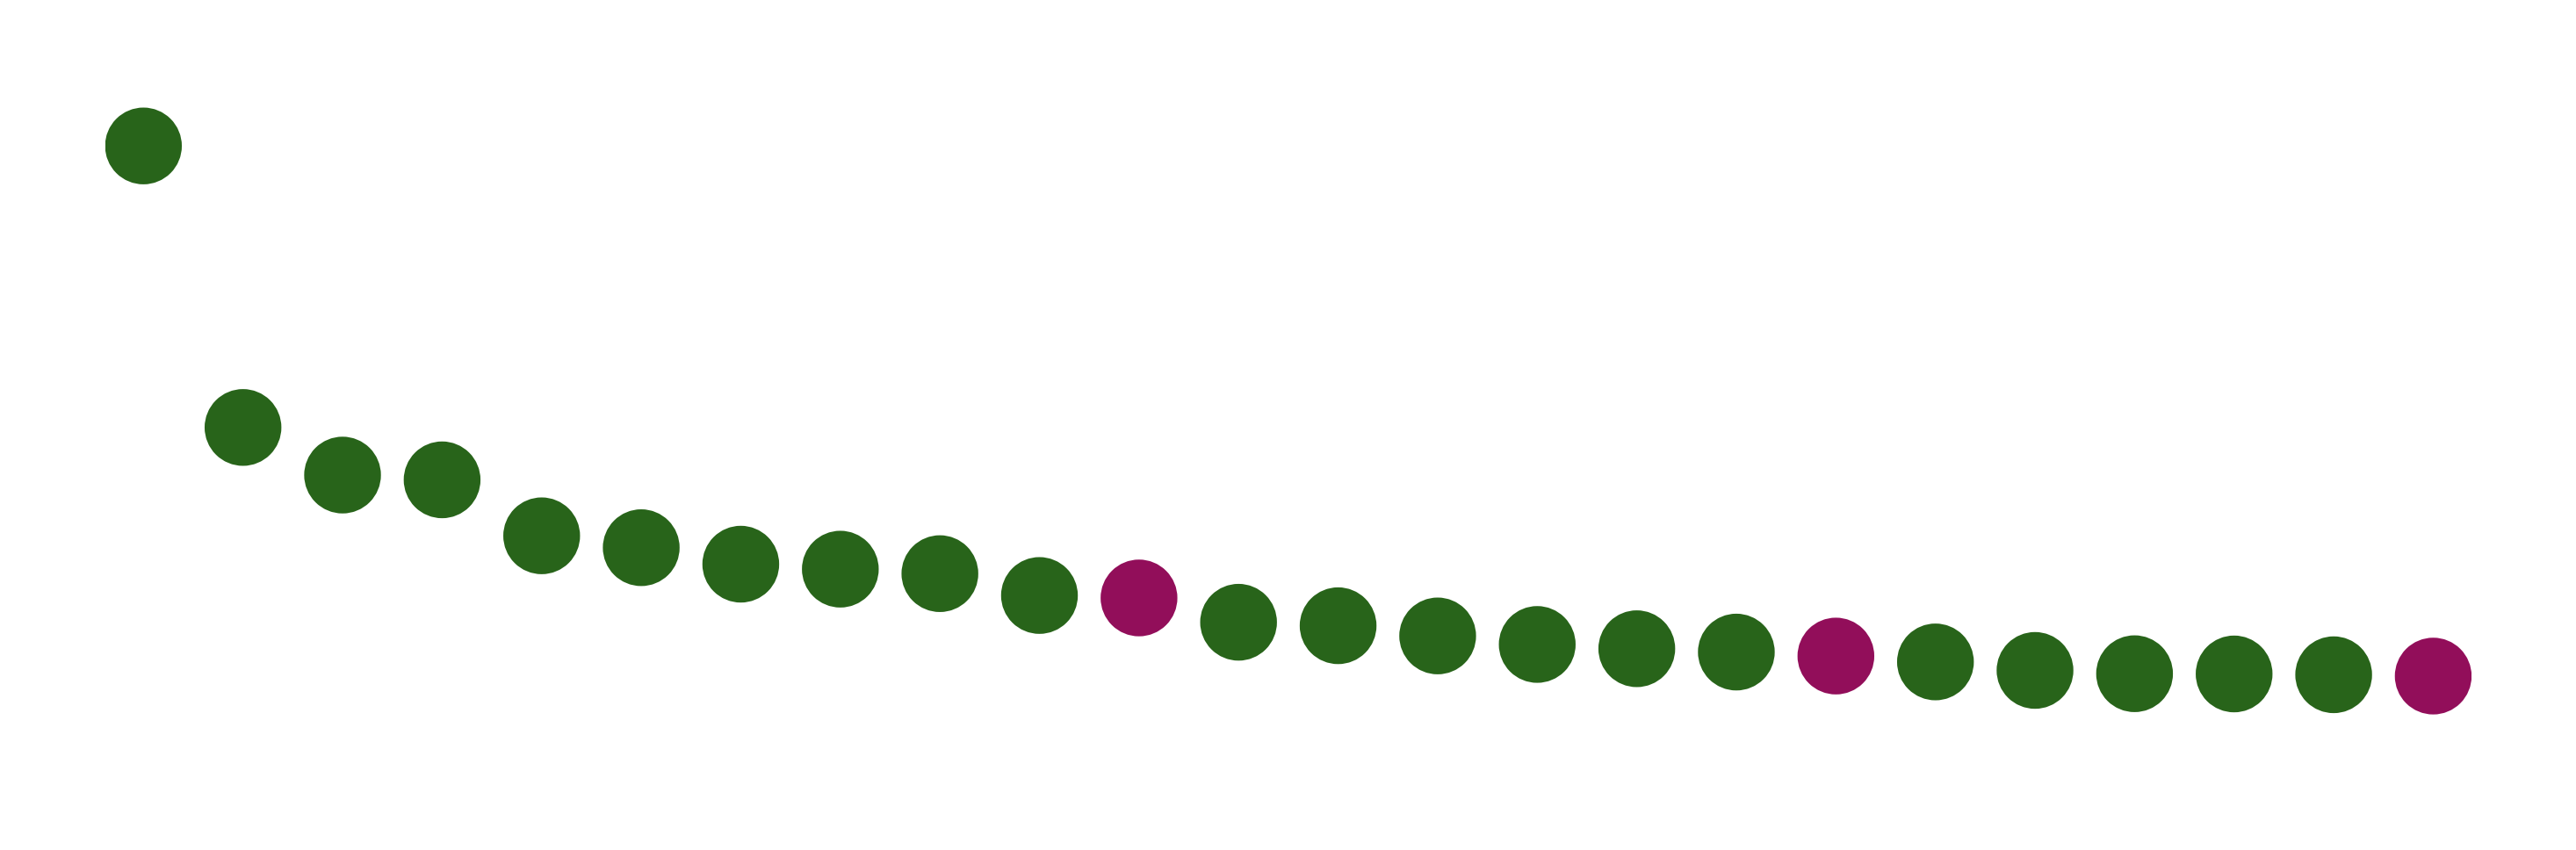

Figure saved to: outputs/celloracle_figures/DT_Subset_Alpha_Delta/STAT1_targets_Alpha_ranked_coefabs.png


['SCN7A',
 'CDH18',
 'GAST',
 'RPL14',
 'RPS12',
 'COX7B',
 'CD99',
 'PSMB5',
 'TPT1',
 'IFI6',
 'SLC14A1',
 'RPS26',
 'LRP1B',
 'EEF1A1',
 'SEC61G',
 'SLC25A3',
 'ATP6V1G1',
 'ATP5F1E',
 'APOA2',
 'WDR83OS',
 'EIF3E',
 'FSTL5',
 'SH3BGRL3',
 'ASPH']

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

cluster_name = "Delta"
tf_name = "STAT1"

filtered_links_df = links.filtered_links[cluster_name]
zeb1_targets = filtered_links_df[filtered_links_df.source == tf_name]

df = zeb1_targets.copy()
df = df.sort_values("coef_abs", ascending=False).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)
df["color"] = np.where(df["coef_mean"] > 0, "#28641A", "#920E5A")

# --- FIXED CANVAS SIZE ---
fig_w, fig_h = 2.44, 0.66
dpi = 600
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

dot_size = 18  # scatter 's' is area in points^2
ax.scatter(df["rank"], df["coef_abs"], c=df["color"], s=dot_size)

# ---- Y limits: fix top at 0.45 ----
ymax_fixed = 0.92
ymin = float(df["coef_abs"].min())

# keep a little padding at the bottom (same logic as before)
yrng = ymax_fixed - ymin
ypad = (0.12 * yrng) if yrng > 0 else 0.01

ax.set_ylim(ymin - ypad, ymax_fixed)

# ---- X padding: computed from marker radius so dots don't get cut ----
xmin, xmax = df["rank"].min(), df["rank"].max()

# Start with tight-ish xlim (0.5 gives half-step breathing room for integer ranks)
ax.set_xlim(xmin - 0.5, xmax + 0.5)

# Add small inner padding INSIDE the fixed canvas (keeps size exact)
pad = 0.04
fig.subplots_adjust(left=pad, right=1-pad, bottom=pad, top=1-pad)

# Force draw so we can measure axis width in pixels
fig.canvas.draw()
bbox = ax.get_window_extent()
ax_width_px = bbox.width

# Marker radius in points -> pixels
marker_radius_pt = np.sqrt(dot_size / np.pi)
marker_radius_px = marker_radius_pt * (dpi / 72.0)

# Add a tiny safety "air" (pixels)
air_px = 1.5

# Convert pixels -> data units for current x range
xrange = ax.get_xlim()[1] - ax.get_xlim()[0]
data_per_px = xrange / ax_width_px

# Minimal padding in data units to keep dot fully visible
xpad_data = (marker_radius_px + air_px) * data_per_px

# Apply final xlim with minimal safe padding
ax.set_xlim(xmin - 0.0 - xpad_data, xmax + 0.0 + xpad_data)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.margins(x=0, y=0)
ax.axis("off")

output_dir = "outputs/celloracle_figures/DT_Subset_Delta"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{tf_name}_targets_{cluster_name}_ranked_coefabs.png")

# IMPORTANT: no bbox_inches="tight" if you need exact final dimensions
fig.savefig(output_path, dpi=dpi, facecolor="white")
plt.show()

print(f"Figure saved to: {output_path}")
targets = df["target"].tolist()
targets


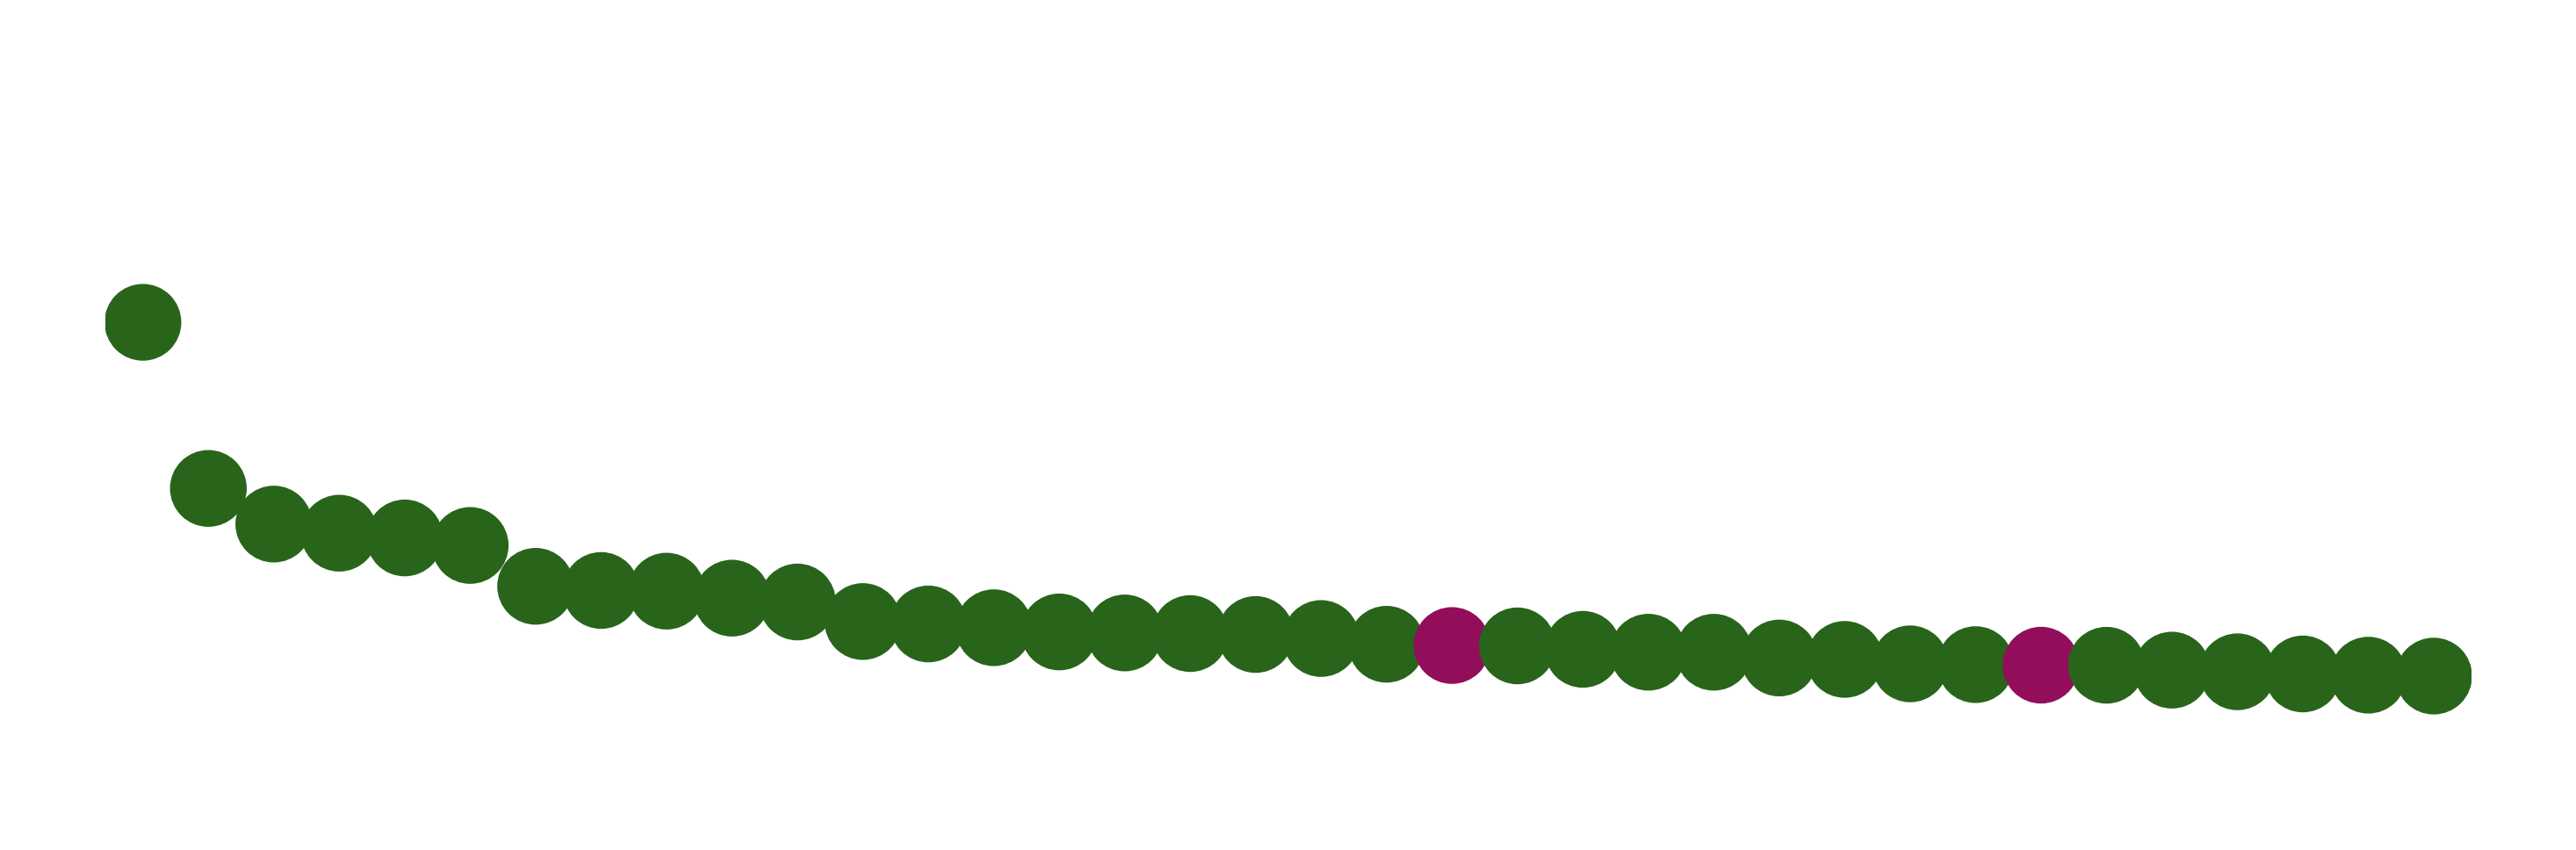

Figure saved to: outputs/celloracle_figures/DT_Subset_Alpha_Delta/STAT1_targets_Delta_ranked_coefabs.png


['GCG',
 'LRP1B',
 'GPC6',
 'RPS12',
 'CDH18',
 'PSMB5',
 'COX7B',
 'RPL14',
 'GAST',
 'RPS27A',
 'SLC25A3',
 'CD99',
 'SCN7A',
 'FSTL5',
 'WDR83OS',
 'SLC35F1',
 'MAN1A1',
 'NDUFB7',
 'APOA2',
 'B2M',
 'CACNA2D3',
 'ISG15',
 'EPSTI1',
 'RPS26',
 'TPT1',
 'NDUFB4',
 'NPM1',
 'TMBIM4',
 'RPS24',
 'TMSB10',
 'EEF1A1',
 'EIF3E',
 'CMTM8',
 'HIST1H2AC',
 'SERPINI1',
 'SCG5']

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

cluster_name = "Delta"
tf_name = "STAT1"

filtered_links_df = links.filtered_links[cluster_name]
zeb1_targets = filtered_links_df[filtered_links_df.source == tf_name]

df = zeb1_targets.copy()
df = df.sort_values("coef_abs", ascending=False).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)
df["color"] = np.where(df["coef_mean"] > 0, "#28641A", "#920E5A")

# --- FIXED CANVAS SIZE ---
fig_w, fig_h = 2.44, 0.66
dpi = 600
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

dot_size = 18  # scatter 's' is area in points^2
ax.scatter(df["rank"], df["coef_abs"], c=df["color"], s=dot_size)

# ---- Y limits: fix top at 0.45 ----
ymax_fixed = 0.92
ymin = float(df["coef_abs"].min())

# keep a little padding at the bottom (same logic as before)
yrng = ymax_fixed - ymin
ypad = (0.12 * yrng) if yrng > 0 else 0.01

ax.set_ylim(ymin - ypad, ymax_fixed)

# ---- X padding: computed from marker radius so dots don't get cut ----
xmin, xmax = df["rank"].min(), df["rank"].max()

# Start with tight-ish xlim (0.5 gives half-step breathing room for integer ranks)
ax.set_xlim(xmin - 0.5, xmax + 0.5)

# Add small inner padding INSIDE the fixed canvas (keeps size exact)
pad = 0.04
fig.subplots_adjust(left=pad, right=1-pad, bottom=pad, top=1-pad)

# Force draw so we can measure axis width in pixels
fig.canvas.draw()
bbox = ax.get_window_extent()
ax_width_px = bbox.width

# Marker radius in points -> pixels
marker_radius_pt = np.sqrt(dot_size / np.pi)
marker_radius_px = marker_radius_pt * (dpi / 72.0)

# Add a tiny safety "air" (pixels)
air_px = 1.5

# Convert pixels -> data units for current x range
xrange = ax.get_xlim()[1] - ax.get_xlim()[0]
data_per_px = xrange / ax_width_px

# Minimal padding in data units to keep dot fully visible
xpad_data = (marker_radius_px + air_px) * data_per_px

# Apply final xlim with minimal safe padding
ax.set_xlim(xmin - 0.0 - xpad_data, xmax + 0.0 + xpad_data)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.margins(x=0, y=0)
ax.axis("off")

output_dir = "outputs/celloracle_figures/DT_Subset_Delta"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{tf_name}_targets_{cluster_name}_ranked_coefabs.png")

# IMPORTANT: no bbox_inches="tight" if you need exact final dimensions
fig.savefig(output_path, dpi=dpi, facecolor="white")
plt.show()

print(f"Figure saved to: {output_path}")
targets = df["target"].tolist()
targets


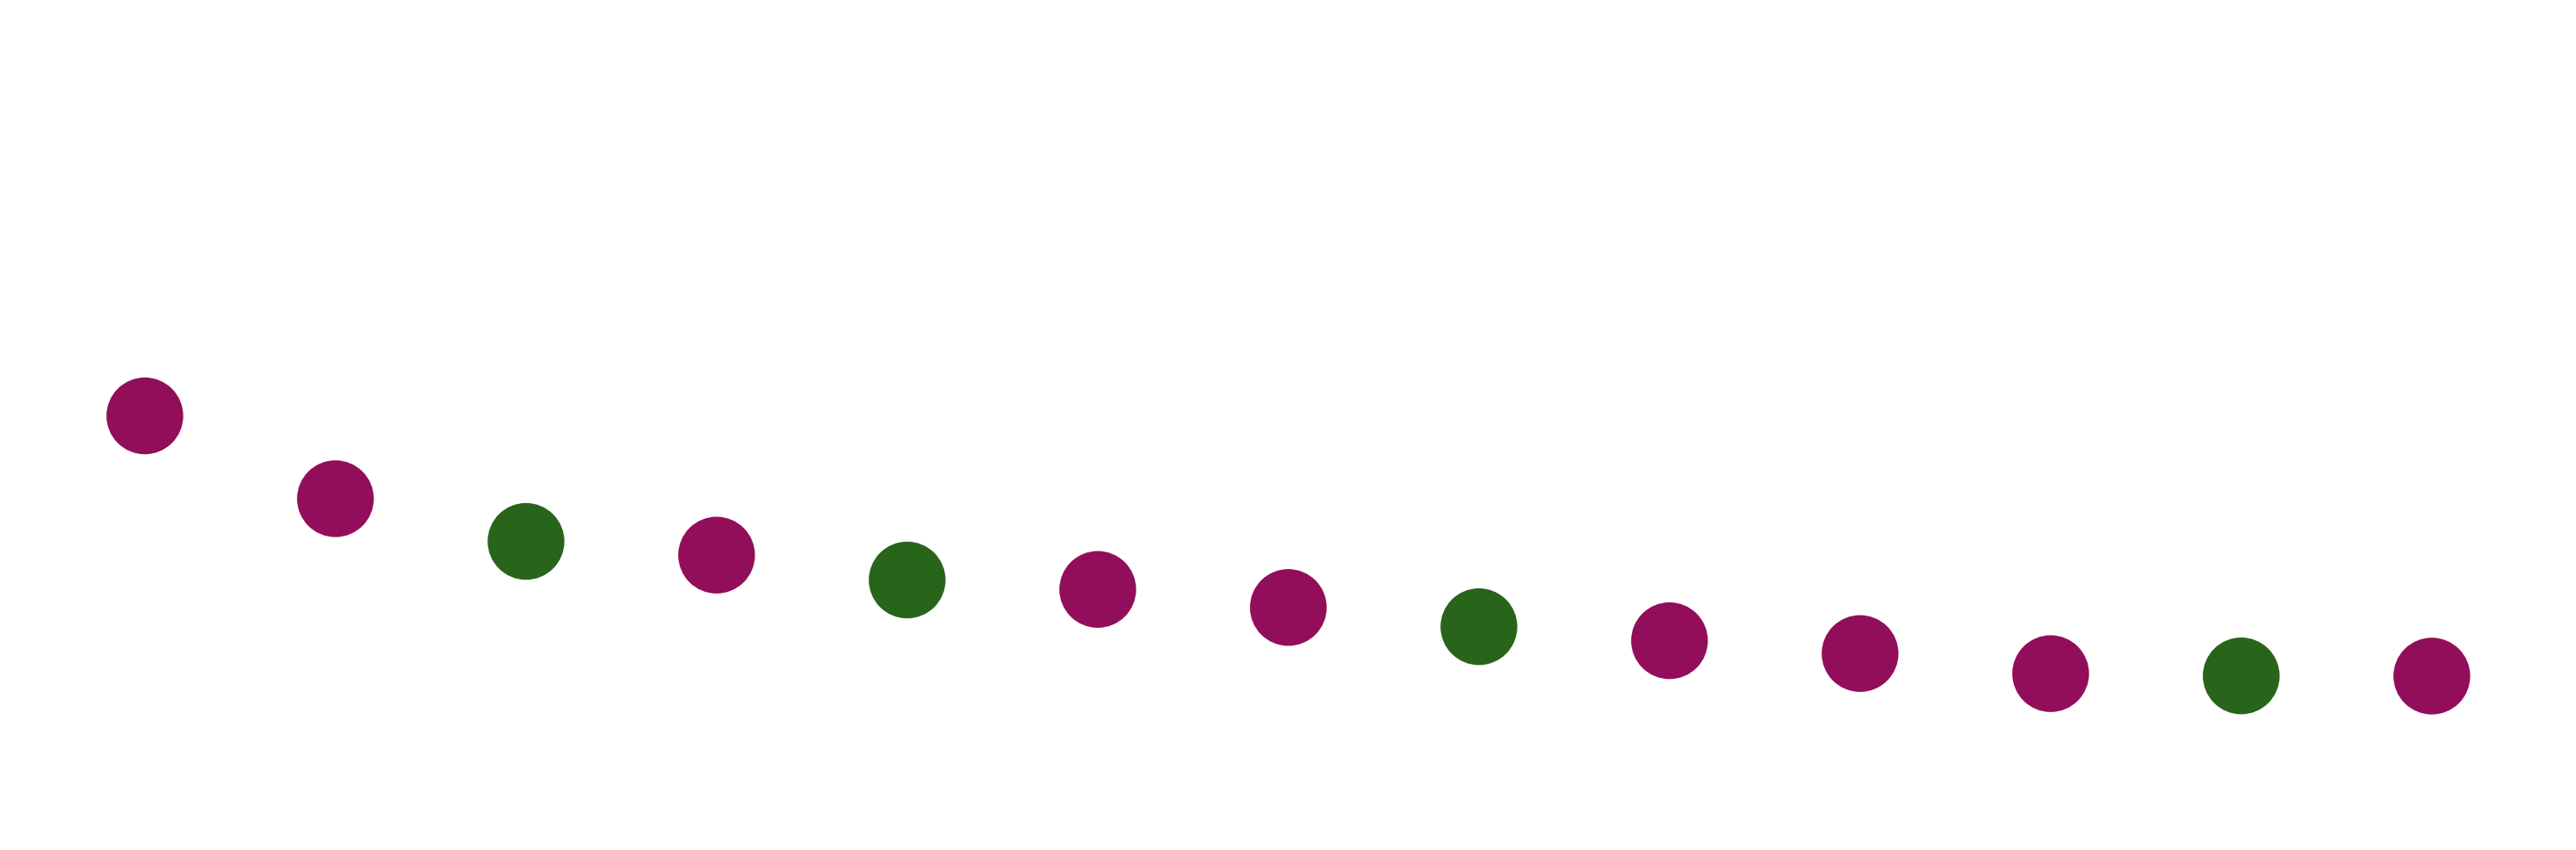

Figure saved to: outputs/celloracle_figures/DT_Subset_Alpha_Delta/ZEB1_targets_Delta_ranked_coefabs.png


['CRH',
 'INS',
 'SYT4',
 'RGS6',
 'KCNB2',
 'DOK6',
 'NEBL',
 'FRY',
 'SAMD5',
 'ERBB4',
 'RPS27A',
 'LINC00907',
 'RPL29']

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

cluster_name = "Delta"
tf_name = "ZEB1"

filtered_links_df = links.filtered_links[cluster_name]
zeb1_targets = filtered_links_df[filtered_links_df.source == tf_name]

df = zeb1_targets.copy()
df = df.sort_values("coef_abs", ascending=False).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)
df["color"] = np.where(df["coef_mean"] > 0, "#28641A", "#920E5A")

# --- FIXED CANVAS SIZE ---
fig_w, fig_h = 2.44, 0.66
dpi = 600
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

dot_size = 18  # scatter 's' is area in points^2
ax.scatter(df["rank"], df["coef_abs"], c=df["color"], s=dot_size)

# ---- Y limits: fix top at 0.45 ----
ymax_fixed = 0.725
ymin = float(df["coef_abs"].min())

# keep a little padding at the bottom (same logic as before)
yrng = ymax_fixed - ymin
ypad = (0.12 * yrng) if yrng > 0 else 0.01

ax.set_ylim(ymin - ypad, ymax_fixed)

# ---- X padding: computed from marker radius so dots don't get cut ----
xmin, xmax = df["rank"].min(), df["rank"].max()

# Start with tight-ish xlim (0.5 gives half-step breathing room for integer ranks)
ax.set_xlim(xmin - 0.5, xmax + 0.5)

# Add small inner padding INSIDE the fixed canvas (keeps size exact)
pad = 0.04
fig.subplots_adjust(left=pad, right=1-pad, bottom=pad, top=1-pad)

# Force draw so we can measure axis width in pixels
fig.canvas.draw()
bbox = ax.get_window_extent()
ax_width_px = bbox.width

# Marker radius in points -> pixels
marker_radius_pt = np.sqrt(dot_size / np.pi)
marker_radius_px = marker_radius_pt * (dpi / 72.0)

# Add a tiny safety "air" (pixels)
air_px = 1.5

# Convert pixels -> data units for current x range
xrange = ax.get_xlim()[1] - ax.get_xlim()[0]
data_per_px = xrange / ax_width_px

# Minimal padding in data units to keep dot fully visible
xpad_data = (marker_radius_px + air_px) * data_per_px

# Apply final xlim with minimal safe padding
ax.set_xlim(xmin - 0.0 - xpad_data, xmax + 0.0 + xpad_data)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.margins(x=0, y=0)
ax.axis("off")

output_dir = "outputs/celloracle_figures/DT_Subset_Delta"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{tf_name}_targets_{cluster_name}_ranked_coefabs.png")

# IMPORTANT: no bbox_inches="tight" if you need exact final dimensions
fig.savefig(output_path, dpi=dpi, facecolor="white")
plt.show()

print(f"Figure saved to: {output_path}")
targets = df["target"].tolist()
targets


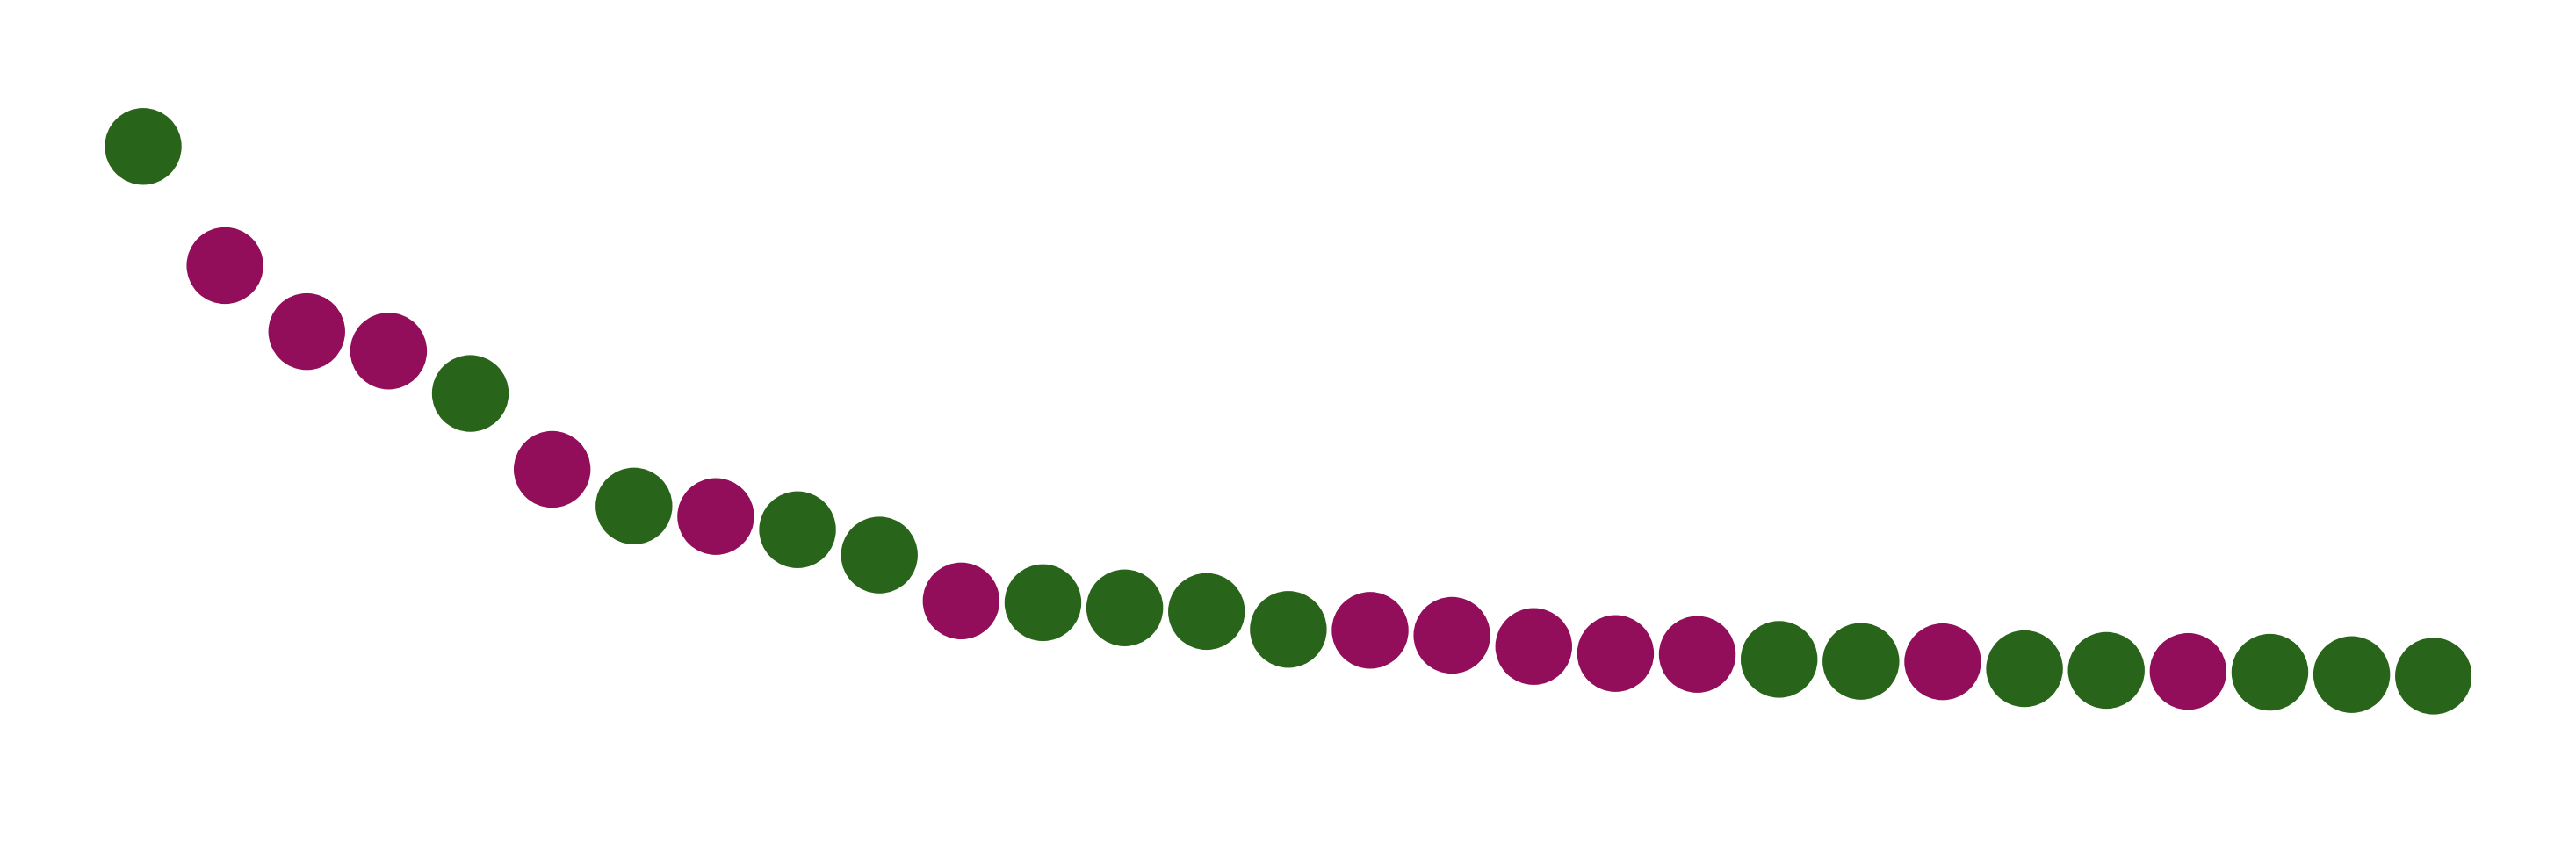

Figure saved to: outputs/celloracle_figures/DT_Subset_Alpha_Delta/ZEB1_targets_Alpha_ranked_coefabs.png


['DCC',
 'GCG',
 'SCG5',
 'RPS27A',
 'ADARB2',
 'INS',
 'CNTNAP5',
 'EEF1A1',
 'PLCB1',
 'CLSTN2',
 'SERPINI1',
 'SLC14A1',
 'NRXN3',
 'WWOX',
 'CALB2',
 'HINT1',
 'CPE',
 'ALDH1A1',
 'RPS5',
 'ST6GALNAC5',
 'KCNB2',
 'TXNIP',
 'MAN1A1',
 'ARFGEF3',
 'NKAIN3',
 'HSPA5',
 'FNBP1L',
 'N4BP2L2',
 'RAB11A']

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

cluster_name = "Delta"
tf_name = "ZEB1"

filtered_links_df = links.filtered_links[cluster_name]
zeb1_targets = filtered_links_df[filtered_links_df.source == tf_name]

df = zeb1_targets.copy()
df = df.sort_values("coef_abs", ascending=False).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)
df["color"] = np.where(df["coef_mean"] > 0, "#28641A", "#920E5A")

# --- FIXED CANVAS SIZE ---
fig_w, fig_h = 2.44, 0.66
dpi = 600
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

dot_size = 18  # scatter 's' is area in points^2
ax.scatter(df["rank"], df["coef_abs"], c=df["color"], s=dot_size)

# ---- Y limits: fix top at 0.45 ----
ymax_fixed = 0.725
ymin = float(df["coef_abs"].min())

# keep a little padding at the bottom (same logic as before)
yrng = ymax_fixed - ymin
ypad = (0.12 * yrng) if yrng > 0 else 0.01

ax.set_ylim(ymin - ypad, ymax_fixed)

# ---- X padding: computed from marker radius so dots don't get cut ----
xmin, xmax = df["rank"].min(), df["rank"].max()

# Start with tight-ish xlim (0.5 gives half-step breathing room for integer ranks)
ax.set_xlim(xmin - 0.5, xmax + 0.5)

# Add small inner padding INSIDE the fixed canvas (keeps size exact)
pad = 0.04
fig.subplots_adjust(left=pad, right=1-pad, bottom=pad, top=1-pad)

# Force draw so we can measure axis width in pixels
fig.canvas.draw()
bbox = ax.get_window_extent()
ax_width_px = bbox.width

# Marker radius in points -> pixels
marker_radius_pt = np.sqrt(dot_size / np.pi)
marker_radius_px = marker_radius_pt * (dpi / 72.0)

# Add a tiny safety "air" (pixels)
air_px = 1.5

# Convert pixels -> data units for current x range
xrange = ax.get_xlim()[1] - ax.get_xlim()[0]
data_per_px = xrange / ax_width_px

# Minimal padding in data units to keep dot fully visible
xpad_data = (marker_radius_px + air_px) * data_per_px

# Apply final xlim with minimal safe padding
ax.set_xlim(xmin - 0.0 - xpad_data, xmax + 0.0 + xpad_data)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.margins(x=0, y=0)
ax.axis("off")

output_dir = "outputs/celloracle_figures/DT_Subset_Delta"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{tf_name}_targets_{cluster_name}_ranked_coefabs.png")

# IMPORTANT: no bbox_inches="tight" if you need exact final dimensions
fig.savefig(output_path, dpi=dpi, facecolor="white")
plt.show()

print(f"Figure saved to: {output_path}")
targets = df["target"].tolist()
targets


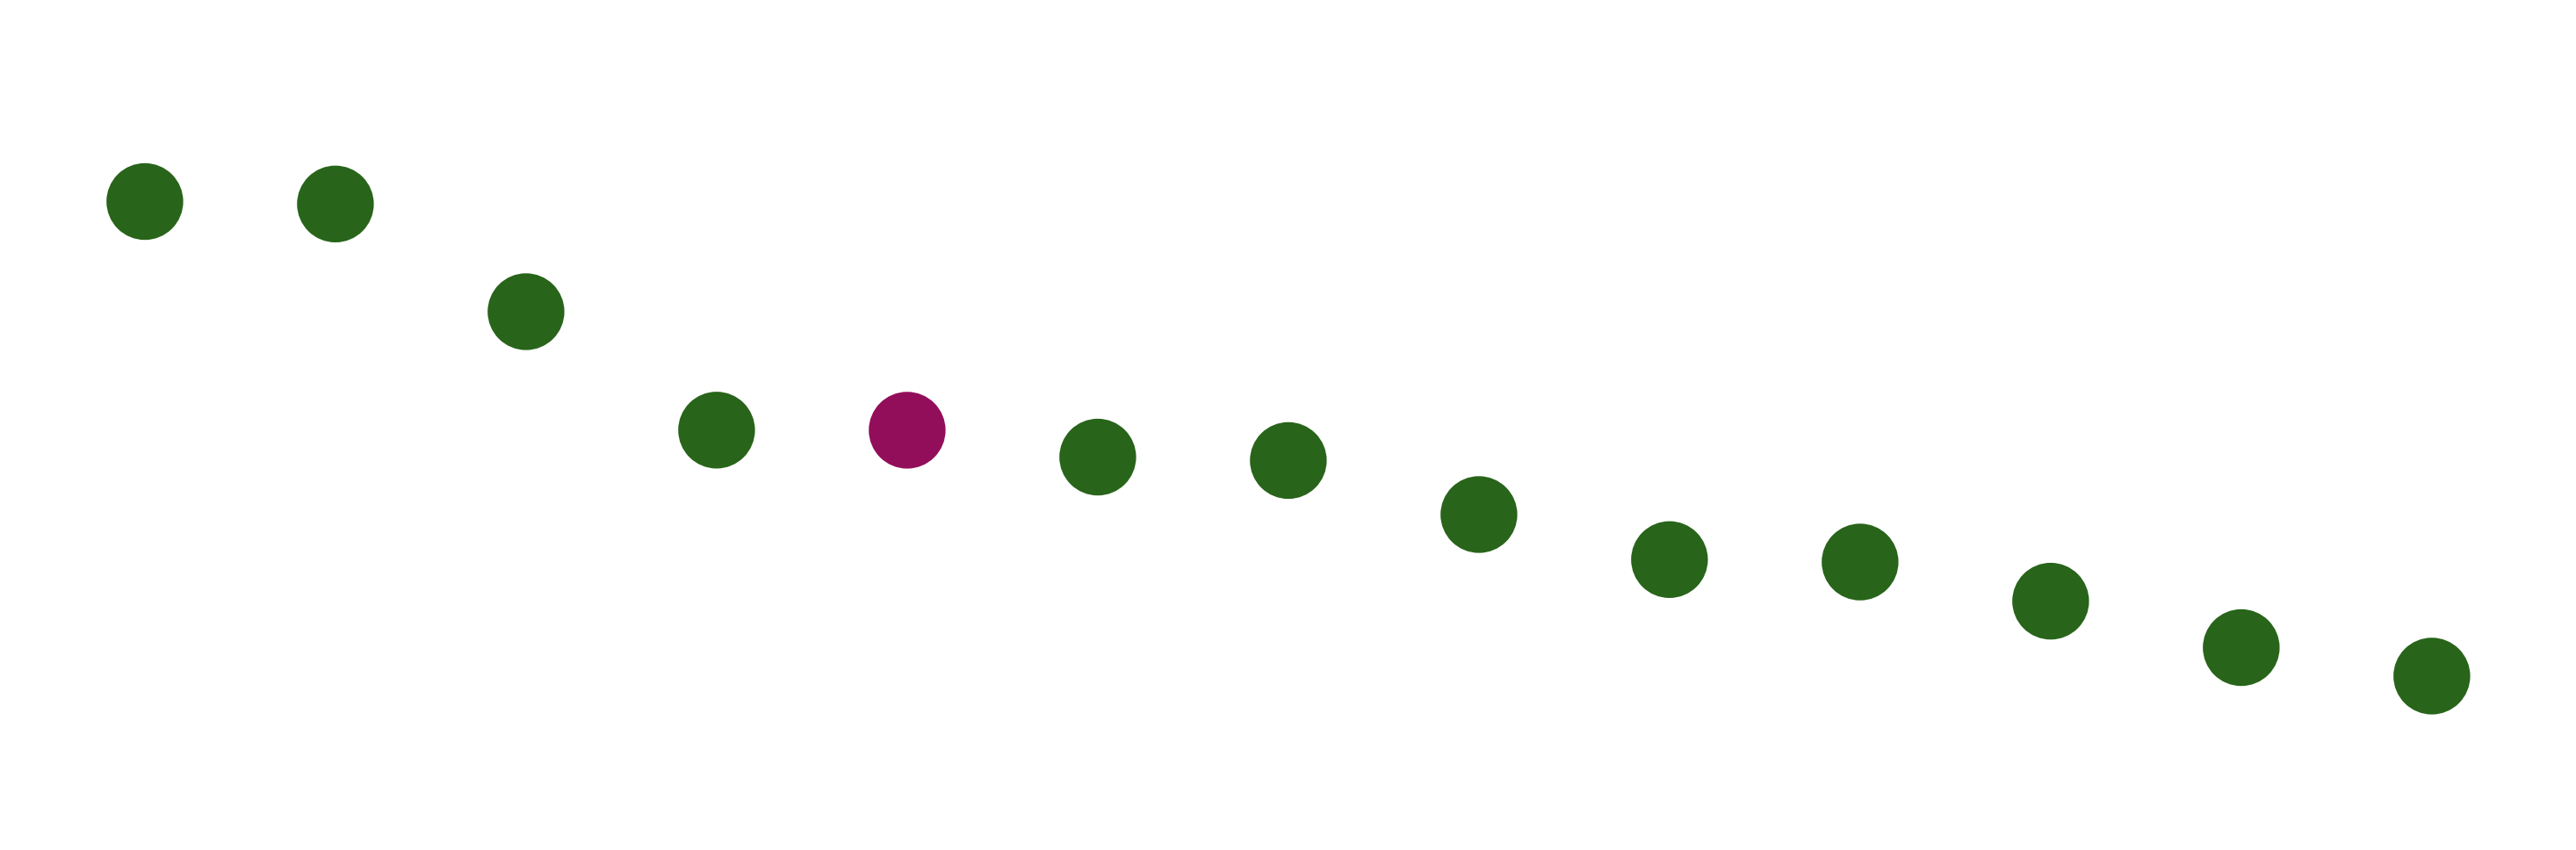

Figure saved to: outputs/celloracle_figures/ranked_score/GATA4_targets_DE_ranked_coefabs.png


['SEMA3E',
 'ARHGAP42',
 'PCDH7',
 'CCDC141',
 'RPL35A',
 'SEMA3A',
 'FGF17',
 'CXCR4',
 'DNAJC15',
 'ANK2',
 'PDE10A',
 'ANK3',
 'GRPR']

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

cluster_name = "DE"
tf_name = "GATA4"

filtered_links_df = links.filtered_links[cluster_name]
zeb1_targets = filtered_links_df[filtered_links_df.source == tf_name]

df = zeb1_targets.copy()
df = df.sort_values("coef_abs", ascending=False).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)
df["color"] = np.where(df["coef_mean"] > 0, "#28641A", "#920E5A")

# --- FIXED CANVAS SIZE ---
fig_w, fig_h = 2.44, 0.66
dpi = 600
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

dot_size = 18  # scatter 's' is area in points^2
ax.scatter(df["rank"], df["coef_abs"], c=df["color"], s=dot_size)

# ---- Y limits: fix top at 0.45 ----
ymax_fixed = 0.45
ymin = float(df["coef_abs"].min())

# keep a little padding at the bottom (same logic as before)
yrng = ymax_fixed - ymin
ypad = (0.12 * yrng) if yrng > 0 else 0.01

ax.set_ylim(ymin - ypad, ymax_fixed)
# ---- X padding: computed from marker radius so dots don't get cut ----
xmin, xmax = df["rank"].min(), df["rank"].max()

# Start with tight-ish xlim (0.5 gives half-step breathing room for integer ranks)
ax.set_xlim(xmin - 0.5, xmax + 0.5)

# Add small inner padding INSIDE the fixed canvas (keeps size exact)
pad = 0.04
fig.subplots_adjust(left=pad, right=1-pad, bottom=pad, top=1-pad)

# Force draw so we can measure axis width in pixels
fig.canvas.draw()
bbox = ax.get_window_extent()
ax_width_px = bbox.width

# Marker radius in points -> pixels
marker_radius_pt = np.sqrt(dot_size / np.pi)
marker_radius_px = marker_radius_pt * (dpi / 72.0)

# Add a tiny safety "air" (pixels)
air_px = 1.5

# Convert pixels -> data units for current x range
xrange = ax.get_xlim()[1] - ax.get_xlim()[0]
data_per_px = xrange / ax_width_px

# Minimal padding in data units to keep dot fully visible
xpad_data = (marker_radius_px + air_px) * data_per_px

# Apply final xlim with minimal safe padding
ax.set_xlim(xmin - 0.0 - xpad_data, xmax + 0.0 + xpad_data)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.margins(x=0, y=0)
ax.axis("off")

output_dir = "outputs/celloracle_figures/ranked_score"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{tf_name}_targets_{cluster_name}_ranked_coefabs.png")

# IMPORTANT: no bbox_inches="tight" if you need exact final dimensions
fig.savefig(output_path, dpi=dpi, facecolor="white")
plt.show()

print(f"Figure saved to: {output_path}")
targets = df["target"].tolist()
targets


In [36]:
# Espabila, que sonreir es gratis - Es Gratis by Arnau Griso